# EDA House rent

Datos tomados de: https://www.kaggle.com/datasets/rkb0023/houserentpredictiondataset

## Contexto

El mercado inmobiliario es un sector dinámico en el que los precios de las viviendas pueden variar según múltiples factores, como la ubicación, el tamaño, las condiciones del mercado y las características de la propiedad. Este dataset fue recopilado por Austin Reese el 7 de enero de 2020 desde Craiglist.org, un sitio web de anuncios clasificados. Contiene 265,190 registros de viviendas con 22 variables, proporcionando una fuente rica para el análisis de precios de inmuebles.

Es posible que los datos presenten ciertas irregularidades, como valores atípicos, información incompleta o inconsistencias en los atributos. Sin embargo, este conjunto de datos representa una excelente oportunidad para aplicar técnicas de exploración, limpieza y modelado predictivo en el ámbito de la analítica de datos inmobiliaria.

## Problema

El objetivo de este proyecto es desarrollar modelos de analítica de datos para predecir dos aspectos clave del mercado inmobiliario:

1. Predicción del precio de la vivienda: Utilizar regresión lineal para estimar el precio de una propiedad en función de sus características. Se busca identificar qué factores tienen mayor impacto en el valor de las viviendas y evaluar la precisión del modelo en distintas condiciones.

2. Clasificación del tipo de casa: Aplicar modelos de regresión logística para predecir el tipo de vivienda en función de sus atributos. Se pretende evaluar cómo las variables del dataset (como el número de habitaciones, baños, tamaño, etc.) pueden ayudar a categorizar correctamente las viviendas en diferentes tipos.

Para abordar este problema, se llevará a cabo un proceso de análisis y modelado, que incluirá:

1. Limpieza de datos: Identificación y tratamiento de valores nulos, inconsistencias y valores atípicos.
2. Análisis exploratorio (EDA): Visualización y evaluación de la relación entre variables.
3. Transformación de datos: Codificación de variables categóricas, escalado de variables numéricas y selección de características relevantes.
4. Entrenamiento y evaluación de modelos: Aplicación de regresión lineal para la predicción de precios y regresión logística para la clasificación del tipo de casa, con métricas de desempeño como RMSE (para regresión) y precisión o F1-score (para clasificación).
5. Optimización de modelos: Ajuste de hiperparámetros y validación cruzada para mejorar el rendimiento.

Este enfoque permitirá no solo comprender los factores que influyen en los precios de las viviendas, sino también desarrollar herramientas predictivas útiles para la toma de decisiones en el sector inmobiliario.

## Paso 1: Importar Liberias

In [1]:
import pandas  as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from bleach.callbacks import target_blank
from requests.packages import target
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import os

C:\Users\guill\Documents\GitHub\taller-house-rent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paso 2: Descargar los datos

In [2]:
path = kagglehub.dataset_download("rkb0023/houserentpredictiondataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\guill\.cache\kagglehub\datasets\rkb0023\houserentpredictiondataset\versions\1


In [3]:
files_in_directory = os.listdir(path)
print("Files in dataset directory:", files_in_directory)

Files in dataset directory: ['houseRent']


In [4]:
files_in_directory = os.listdir(f"{path}/houseRent")
print("Files in dataset directory:", files_in_directory)

Files in dataset directory: ['housePricing.docx', 'housing_train.csv']


In [5]:
df = pd.read_csv(f"{path}/houseRent/housing_train.csv")

In [6]:
df.shape

(265190, 22)

In [7]:
df.head()

,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7039061606,https://bham.craigslist.org/apa/d/birmingham-h...,birmingham,https://bham.craigslist.org,1195,apartment,1908,3,2.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00L0L_80pNkyDeG0...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
1,7041970863,https://bham.craigslist.org/apa/d/birmingham-w...,birmingham,https://bham.craigslist.org,1120,apartment,1319,3,2.0,1,...,0,0,0,laundry on site,off-street parking,https://images.craigslist.org/00707_uRrY9CsNMC...,Find Your Way to Haven Apartment Homes Come ho...,33.3755,-86.8045,al
2,7041966914,https://bham.craigslist.org/apa/d/birmingham-g...,birmingham,https://bham.craigslist.org,825,apartment,1133,1,1.5,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00h0h_b7Bdj1NLBi...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
3,7041966936,https://bham.craigslist.org/apa/d/birmingham-f...,birmingham,https://bham.craigslist.org,800,apartment,927,1,1.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00808_6ghZ8tSRQs...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al
4,7041966888,https://bham.craigslist.org/apa/d/birmingham-2...,birmingham,https://bham.craigslist.org,785,apartment,1047,2,1.0,1,...,0,0,0,laundry on site,street parking,https://images.craigslist.org/00y0y_21c0FOvUXm...,Apartments In Birmingham AL Welcome to 100 Inv...,33.4226,-86.7065,al


In [8]:
df.tail()

,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
265185,7050851033,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,0,apartment,1061,2,2.0,1,...,0,0,0,w/d in unit,detached garage,https://images.craigslist.org/00m0m_8wP9hX96TZ...,â BERKLEY HOUSE â Voted #1 BEST Communit...,40.0495,-83.0669,oh
265186,7050887997,https://columbus.craigslist.org/apa/d/grove-ci...,columbus,https://columbus.craigslist.org,1069,apartment,1020,2,1.5,1,...,0,0,0,w/d hookups,detached garage,https://images.craigslist.org/00N0N_ioCvFNCv24...,!!!!Tour today and receive $5 Starbucks gift c...,39.8408,-83.0804,oh
265187,7044801015,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,1507,apartment,1660,2,1.5,1,...,0,0,0,NaN,NaN,https://images.craigslist.org/00j0j_5EIRWzdHCV...,"The Commons at Olentangy4765 Blairfield Dr, Co...",40.0564,-83.0417,oh
265188,7050885800,https://columbus.craigslist.org/apa/d/newark-l...,columbus,https://columbus.craigslist.org,1001,apartment,1220,3,1.5,1,...,0,0,0,w/d hookups,off-street parking,https://images.craigslist.org/00J0J_6VSTqFJb86...,www.McMillenWoods.com www.mcmillenwoods.com ...,40.0451,-82.4564,oh
265189,7050884586,https://columbus.craigslist.org/apa/d/columbus...,columbus,https://columbus.craigslist.org,1164,townhouse,1300,2,2.5,1,...,0,0,0,w/d hookups,attached garage,https://images.craigslist.org/00w0w_h1L3gxb8rG...,Park Club apartments is offering some of the B...,NaN,NaN,NaN


## Paso 3: Análisis de datos

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265190 entries, 0 to 265189
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       265190 non-null  int64  
 1   url                      265190 non-null  object 
 2   region                   265190 non-null  object 
 3   region_url               265190 non-null  object 
 4   price                    265190 non-null  int64  
 5   type                     265190 non-null  object 
 6   sqfeet                   265190 non-null  int64  
 7   beds                     265190 non-null  int64  
 8   baths                    265190 non-null  float64
 9   cats_allowed             265190 non-null  int64  
 10  dogs_allowed             265190 non-null  int64  
 11  smoking_allowed          265190 non-null  int64  
 12  wheelchair_access        265190 non-null  int64  
 13  electric_vehicle_charge  265190 non-null  int64  
 14  come

In [10]:
df.dtypes

id                           int64
url                         object
region                      object
region_url                  object
price                        int64
type                        object
sqfeet                       int64
beds                         int64
baths                      float64
cats_allowed                 int64
dogs_allowed                 int64
smoking_allowed              int64
wheelchair_access            int64
electric_vehicle_charge      int64
comes_furnished              int64
laundry_options             object
parking_options             object
image_url                   object
description                 object
lat                        float64
long                       float64
state                       object
dtype: object

## Paso 4: Gestión de duplicaciones y valores faltantes

### 4.1 Manejo de duplicaciones

In [11]:
duplicates = df.duplicated().sum()

In [12]:
print(f"Número de registros duplicados: {duplicates}")

Número de registros duplicados: 0


### 4.2 Manejo de valores faltantes

In [13]:
len(df)

265190

In [14]:
missing_data = df.isnull().sum()[df.isnull().sum() > 0]

In [15]:
missing_data

laundry_options    54311
parking_options    95135
description            2
lat                 1419
long                1419
state                  1
dtype: int64

In [16]:
#Listar las variables con valores nulos
vars_null = [var for var in df.columns if df[var].isnull().sum() > 0]
print(len(vars_null))
#ordenar las variables con faltantes según su proporcion
df[vars_null].isnull().mean().sort_values(ascending=False)

6


parking_options    0.358743
laundry_options    0.204800
lat                0.005351
long               0.005351
description        0.000008
state              0.000004
dtype: float64

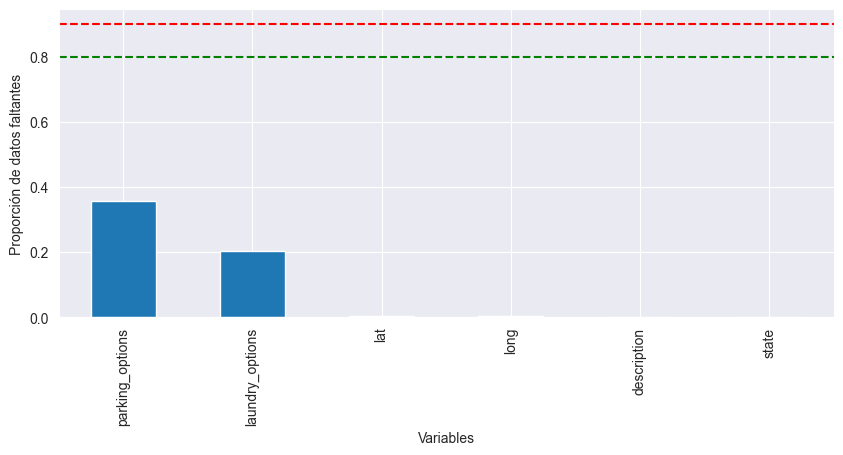

In [17]:
df[vars_null].isnull().mean().sort_values(ascending=False).plot.bar(figsize=(10,4))
plt.ylabel('Proporción de datos faltantes')
plt.xlabel('Variables')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.axhline(y=0.80, color='g', linestyle='--')
plt.show()

In [18]:
df['state'].value_counts()

state
ca    33085
fl    31929
nc    18628
mi    14529
ga    13841
co    11308
ny     9991
il     9706
ks     7910
ia     7488
mn     7468
md     7451
la     7304
az     6752
oh     6558
in     6416
al     6198
nj     5711
ky     5419
ms     4973
ma     4926
id     4466
ct     3765
nd     3428
ar     3149
nm     2917
nv     2846
ne     2697
dc     2502
ak     2169
mo     2158
de     2048
hi     1840
nh     1761
mt     1339
me      420
ok       49
or       44
Name: count, dtype: int64

In [19]:
freq_encoding = df['state'].value_counts().idxmax()
df['state'].fillna(freq_encoding, inplace=True)

C:\Users\guill\AppData\Local\Temp\ipykernel_45780\1321309039.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['state'].fillna(freq_encoding, inplace=True)


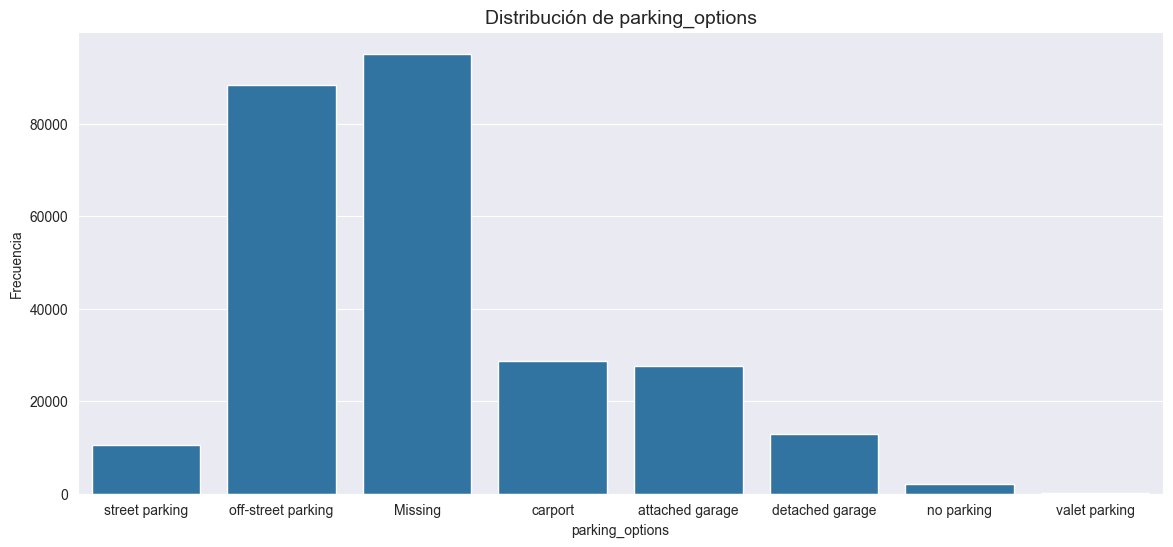

In [20]:
df_missing = df.assign(parking_options=df["parking_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="parking_options")
plt.title('Distribución de parking_options', fontsize=14)
plt.xlabel("parking_options")
plt.ylabel('Frecuencia')
plt.show()

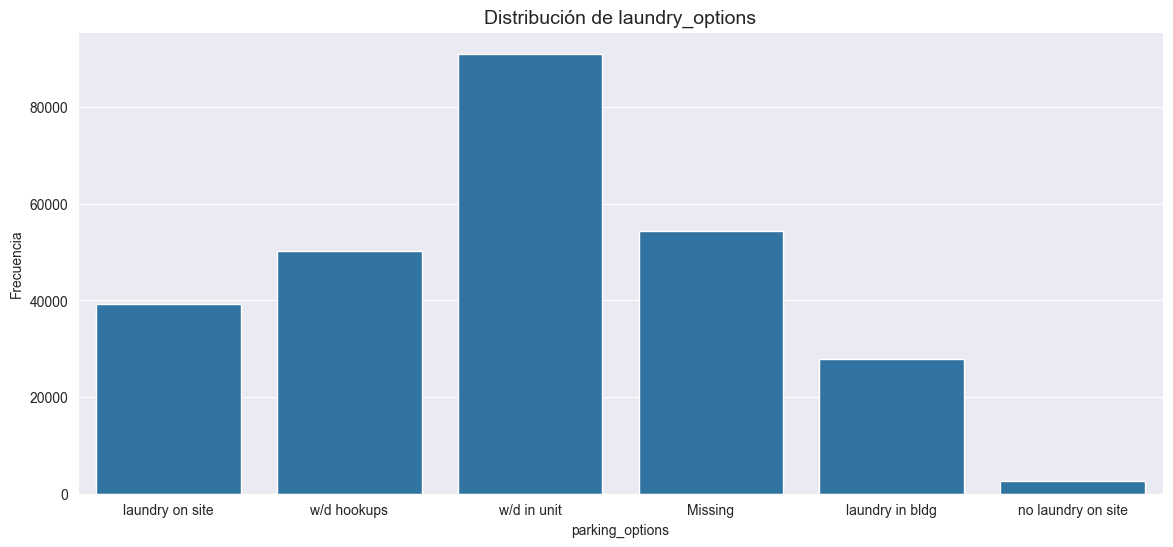

In [21]:
df_missing = df.assign(laundry_options=df["laundry_options"].fillna("Missing"))
plt.figure(figsize=(14, 6))
sns.countplot(data=df_missing, x="laundry_options")
plt.title('Distribución de laundry_options', fontsize=14)
plt.xlabel("parking_options")
plt.ylabel('Frecuencia')
plt.show()

## Paso 5:  Reducción de Datos

In [22]:
## Check "parking_options", "laundry_options"
data = df.drop(columns=["id", "url", "region_url", "image_url", "description", "lat", "long", "parking_options", "laundry_options"])


## Paso 6: Ingeniería de Características (Feature Engineering)

### Paso 6.1: Crear Caracteristicas

In [23]:
data["price_per_sqfeet"] = data["price"] / data["sqfeet"]
data["baths_per_beds"] = data["baths"] / data["beds"]
data["beds_per_sqfeet"] = data["beds"] / data["sqfeet"]

data["baths_per_beds"] = data["baths_per_beds"].apply(lambda x: x if np.isfinite(x) else 0)

## Paso 7: Limpieza y Manipulación de Datos

In [24]:
luxury_threshold = data['price'].quantile(0.85)
data['home_type'] = data['price'].apply(lambda x: 'Luxury Home' if x >= luxury_threshold else 'Standard Home')

In [25]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data_cleaned = remove_outliers(data, 'price')
data_cleaned = remove_outliers(data_cleaned, 'sqfeet')

In [26]:
data_cleaned = data_cleaned[data_cleaned["price"] != 0]


## Paso 8: Agrupar las variables según el tipo

### Paso 8.1: Guardar la variable objetivo

In [107]:
target_var_num = "price"

In [108]:
target_var_cat = "home_type"

### Paso 8.2: Guardar las variables categorias

In [29]:
vars_cat = [var for var in data.columns if (data[var].dtype == "O"
            or var == "cats_allowed"
            or var == "dogs_allowed"
            or var == "smoking_allowed"
            or var == "wheelchair_access"
            or var == "electric_vehicle_charge"
            or var == "comes_furnished")
            and var != target_var_cat]

In [30]:
vars_cat

['region',
 'type',
 'cats_allowed',
 'dogs_allowed',
 'smoking_allowed',
 'wheelchair_access',
 'electric_vehicle_charge',
 'comes_furnished',
 'state']

### Paso 8.3 Guardar las variables númericas

In [31]:
vars_nums = [var for var in data.columns if data[var].dtype != "O" and var != "price" and var not in vars_cat]

In [32]:
vars_nums

['sqfeet',
 'beds',
 'baths',
 'price_per_sqfeet',
 'baths_per_beds',
 'beds_per_sqfeet']

### Paso 8.4 Variables discretas

In [33]:
vars_disc = ["beds", "baths"]

In [34]:
vars_con = ["sqfeet","price_per_sqfeet", "baths_per_beds", "beds_per_sqfeet"]

## Paso 9: Análisis Univariado

### Paso 9.1: Análisis Univeriado de Variables Categorías

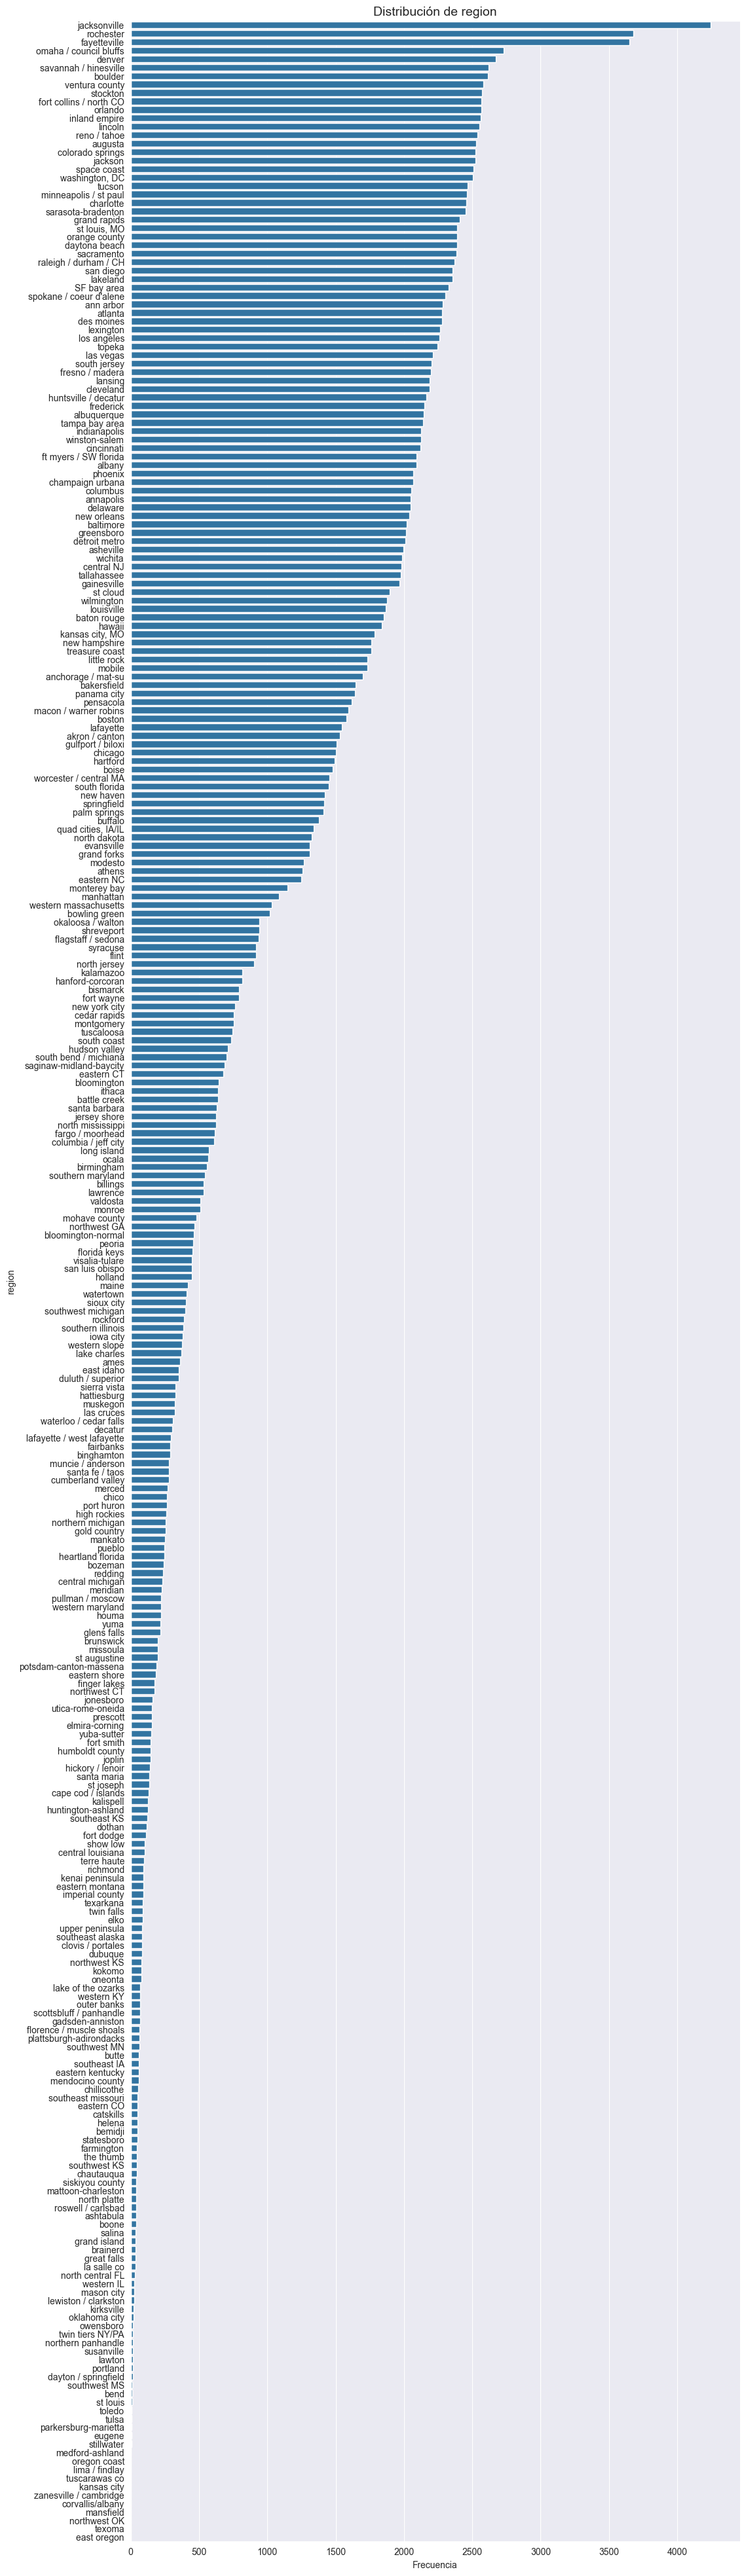

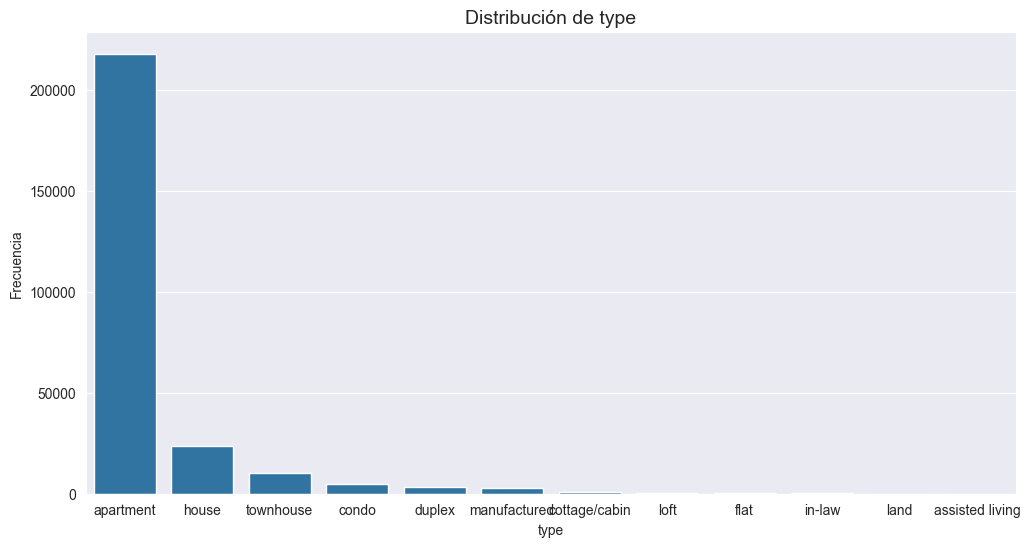

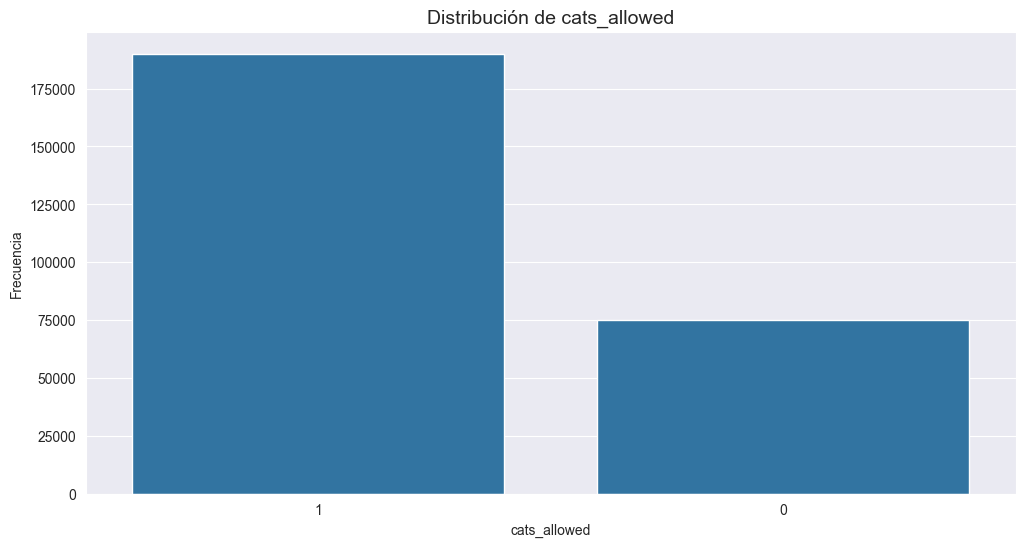

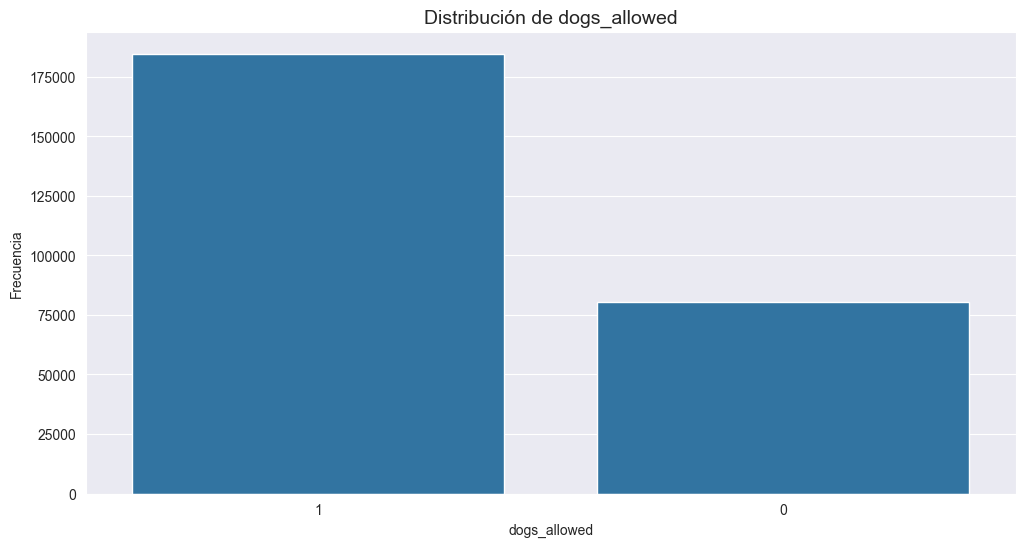

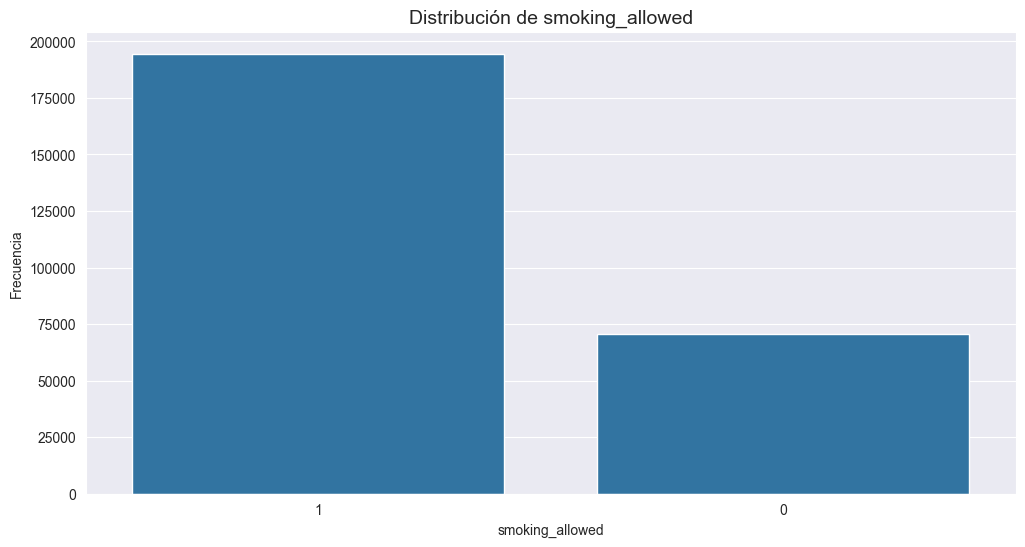

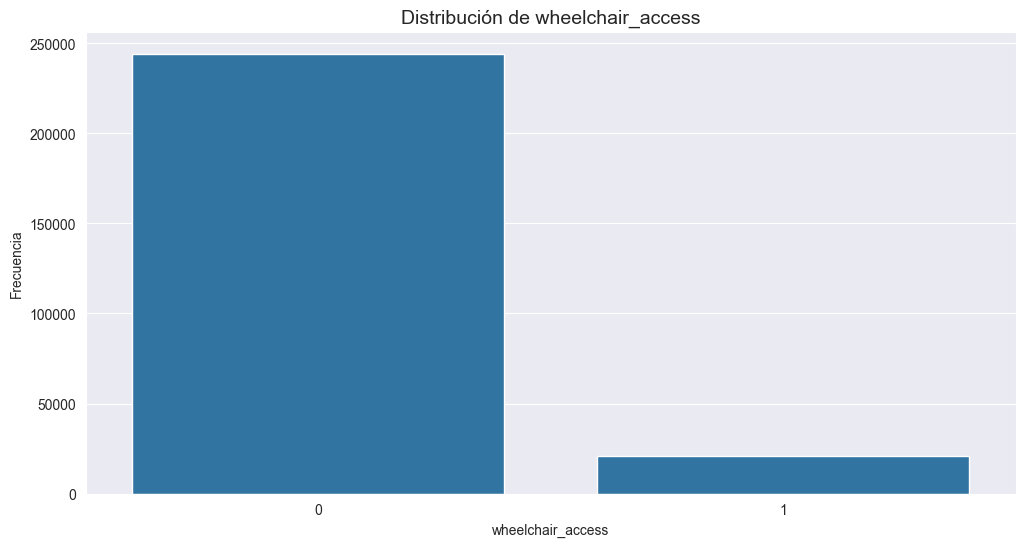

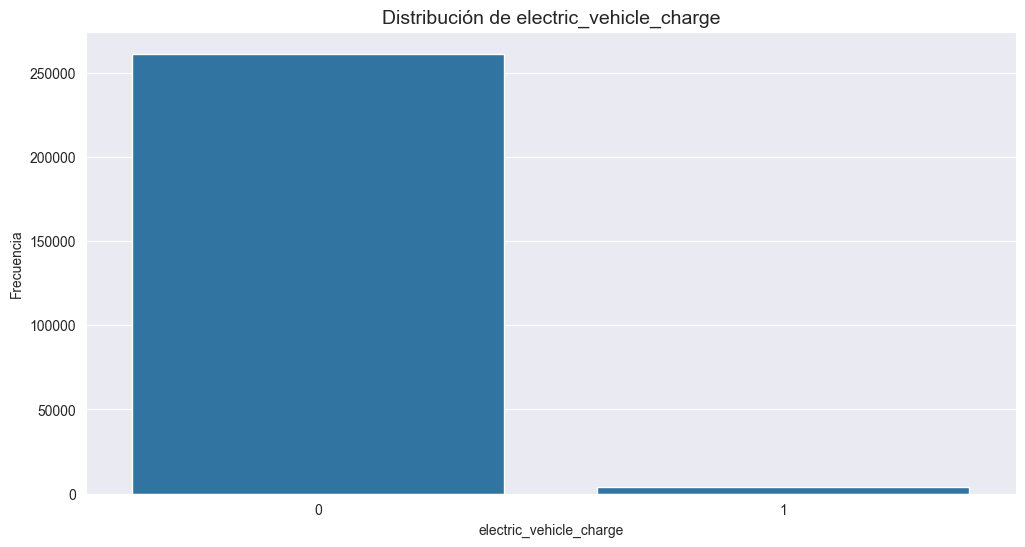

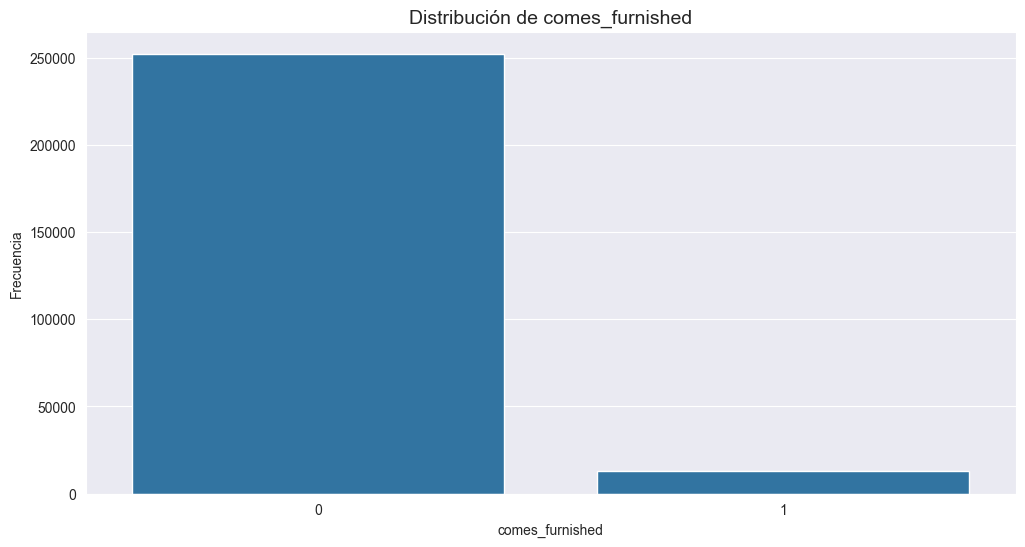

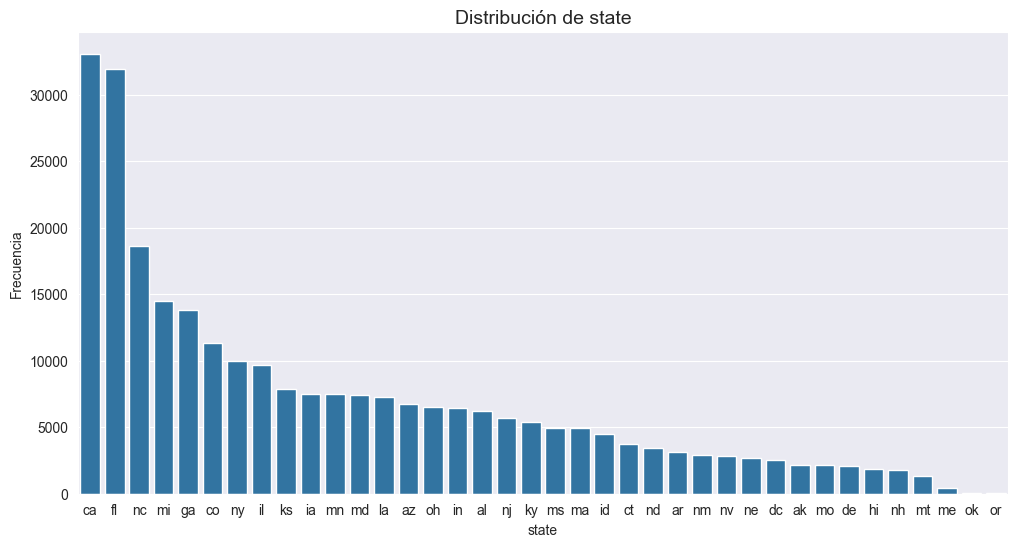

In [35]:
for var in vars_cat:
    order = data[var].value_counts().index
    if var == "region":
        plt.figure(figsize=(12, 50))
        sns.countplot(data=data, y=var, order=order)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel('Frecuencia')
        plt.ylabel(var)

    else:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=var, order=order)
        plt.title(f'Distribución de {var}', fontsize=14)
        plt.xlabel(var)
        plt.ylabel('Frecuencia')
    plt.show()

### Paso 9.2: Análisis Univeriado de Variables Númericas

In [36]:
data[vars_disc].value_counts()

beds  baths
1     1.0      78139
2     2.0      60112
      1.0      44257
3     2.0      29446
2     1.5      12245
               ...  
7     5.5          1
      8.5          1
      7.5          1
8     8.0          1
1000  35.0         1
Name: count, Length: 94, dtype: int64

#### Paso 9.2.1: Análisis Univeriado de Variables Discretas

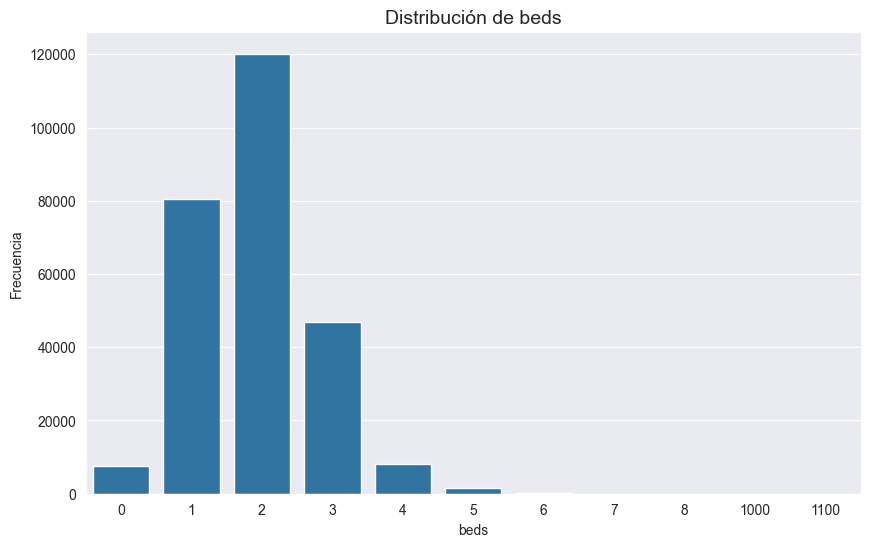

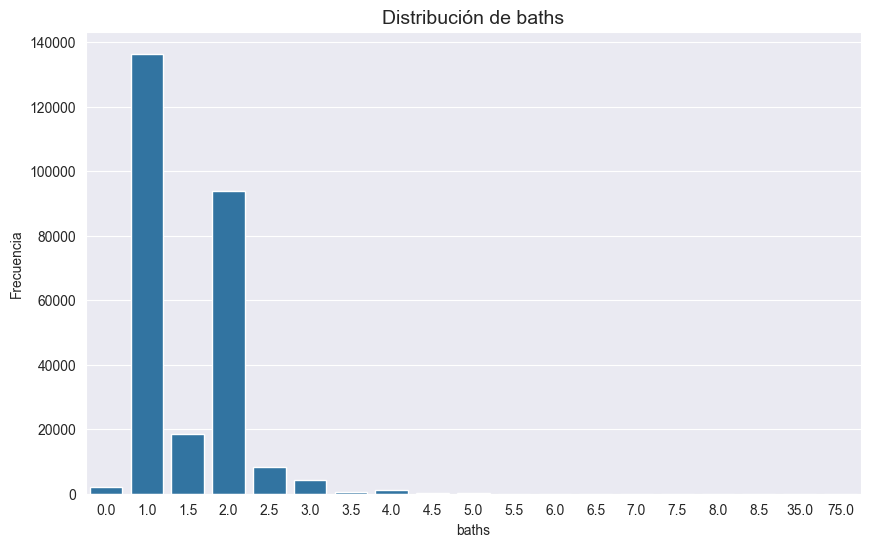

In [37]:
for var in vars_disc:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=var)
    plt.title(f'Distribución de {var}', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

#### Paso 9.2.2: Análisis Univeriado de Variables Continuas

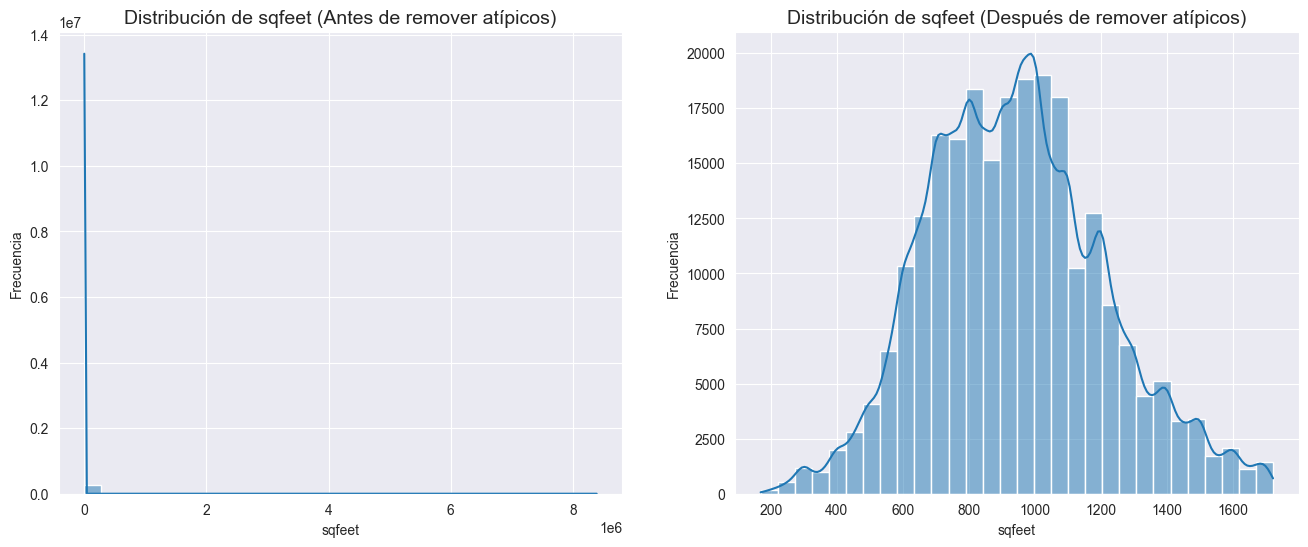

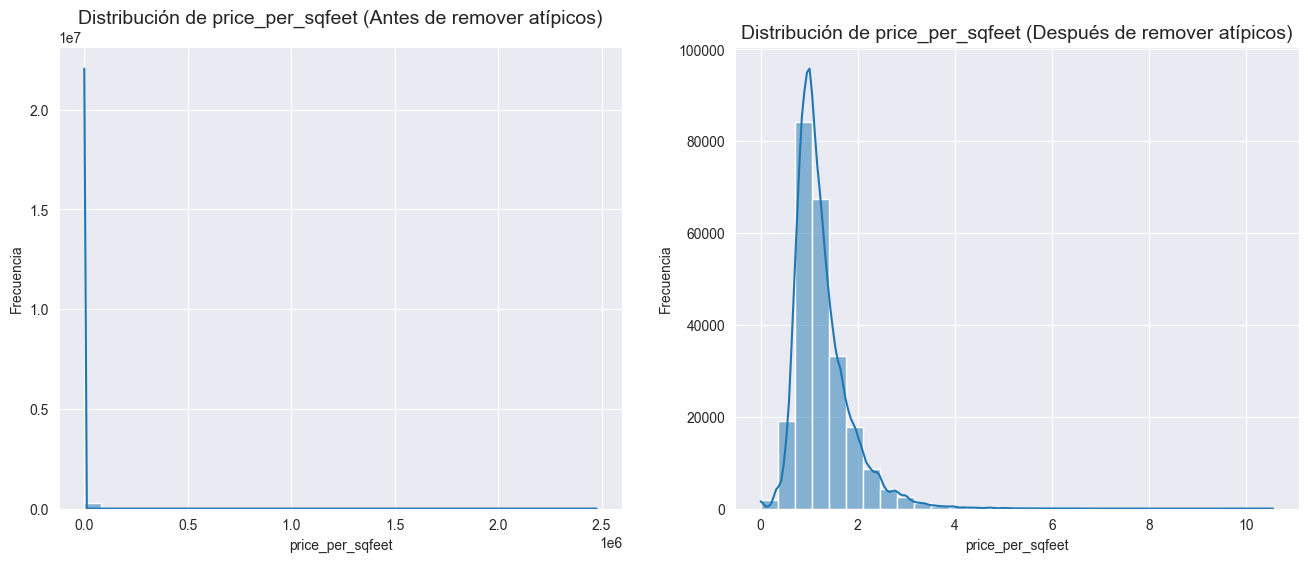

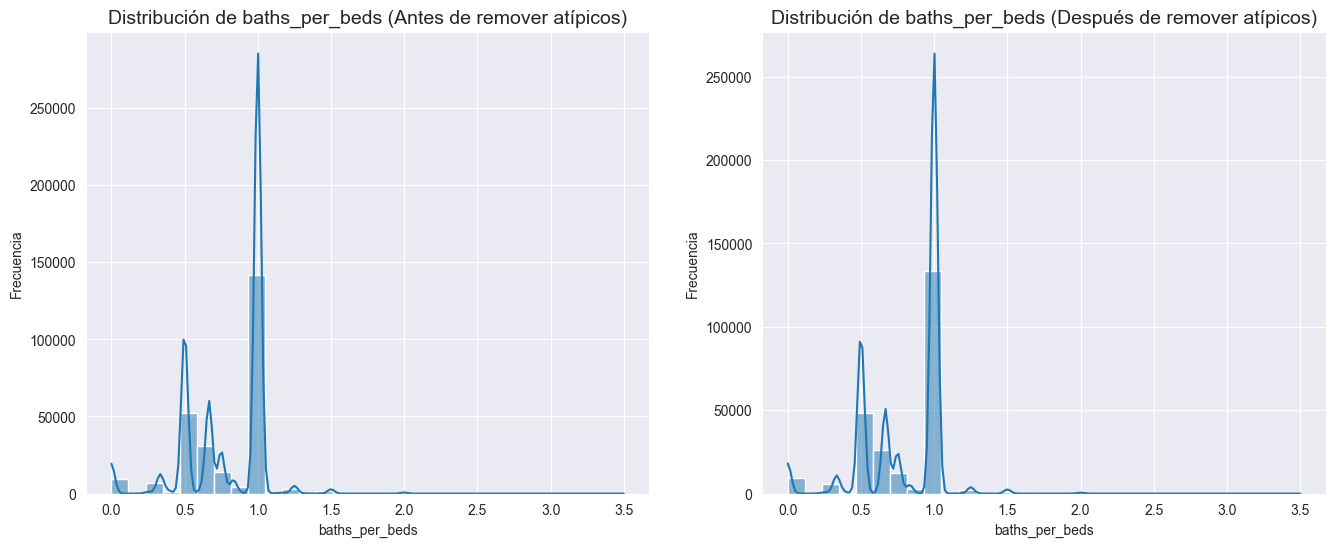

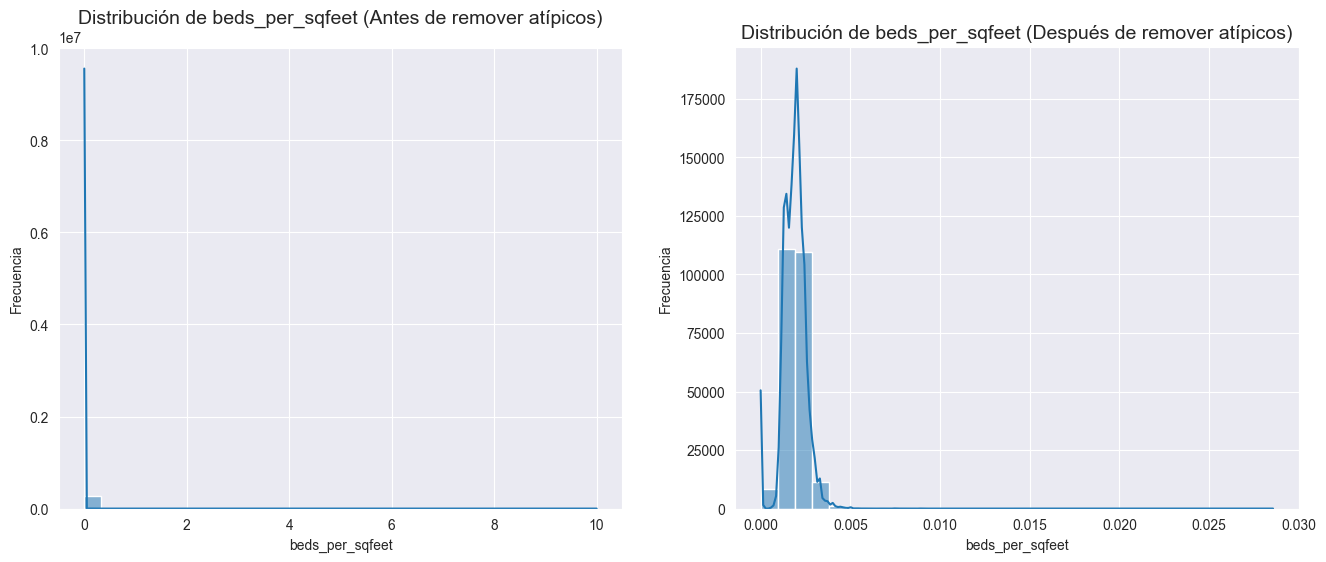

In [38]:
for var in vars_con:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(data[var], kde=True, bins=30)
    plt.title(f'Distribución de {var} (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

    plt.subplot(1, 2, 2)
    sns.histplot(data_cleaned[var], kde=True, bins=30)
    plt.title(f'Distribución de {var} (Después de remover atípicos)', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()

### Paso 9.3: Análisis Univeriado del Variable Objetivo

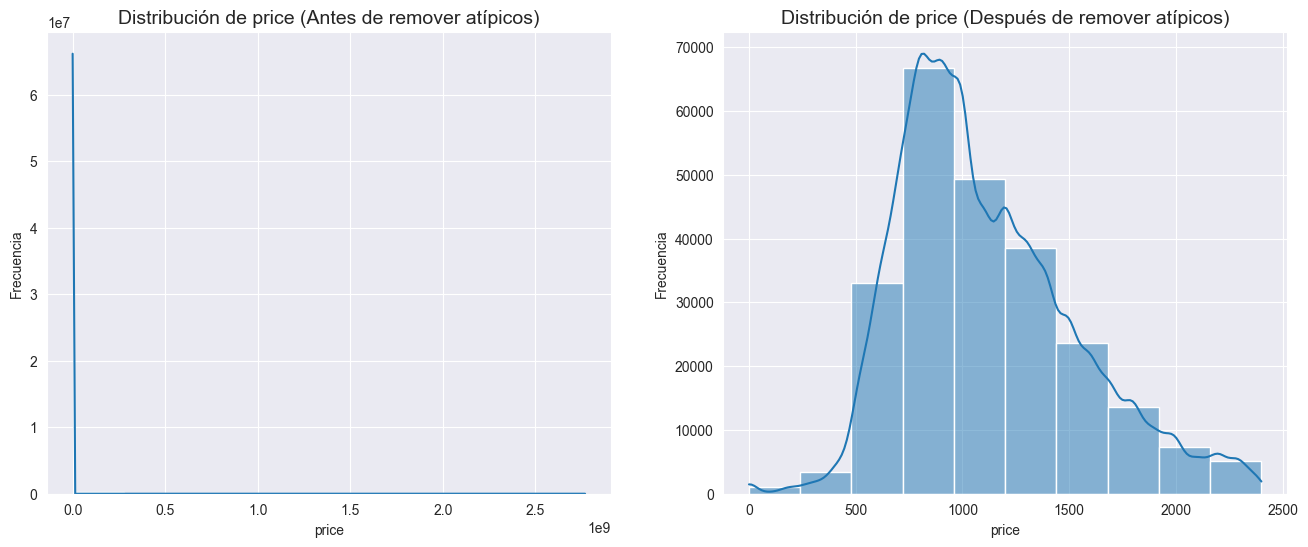

In [39]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(data[target_var_num], kde=True, bins=10)
plt.title(f'Distribución de {target_var_num} (Antes de remover atípicos)', fontsize=14)
plt.xlabel(target_var_num)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned[target_var_num], kde=True, bins=10)
plt.title(f'Distribución de {target_var_num} (Después de remover atípicos)', fontsize=14)
plt.xlabel(target_var_num)
plt.ylabel('Frecuencia')
plt.show()


## Paso 10: Análisis Bivariado

### Paso 10.1: Análisis Bivariado: Relación con el Precio

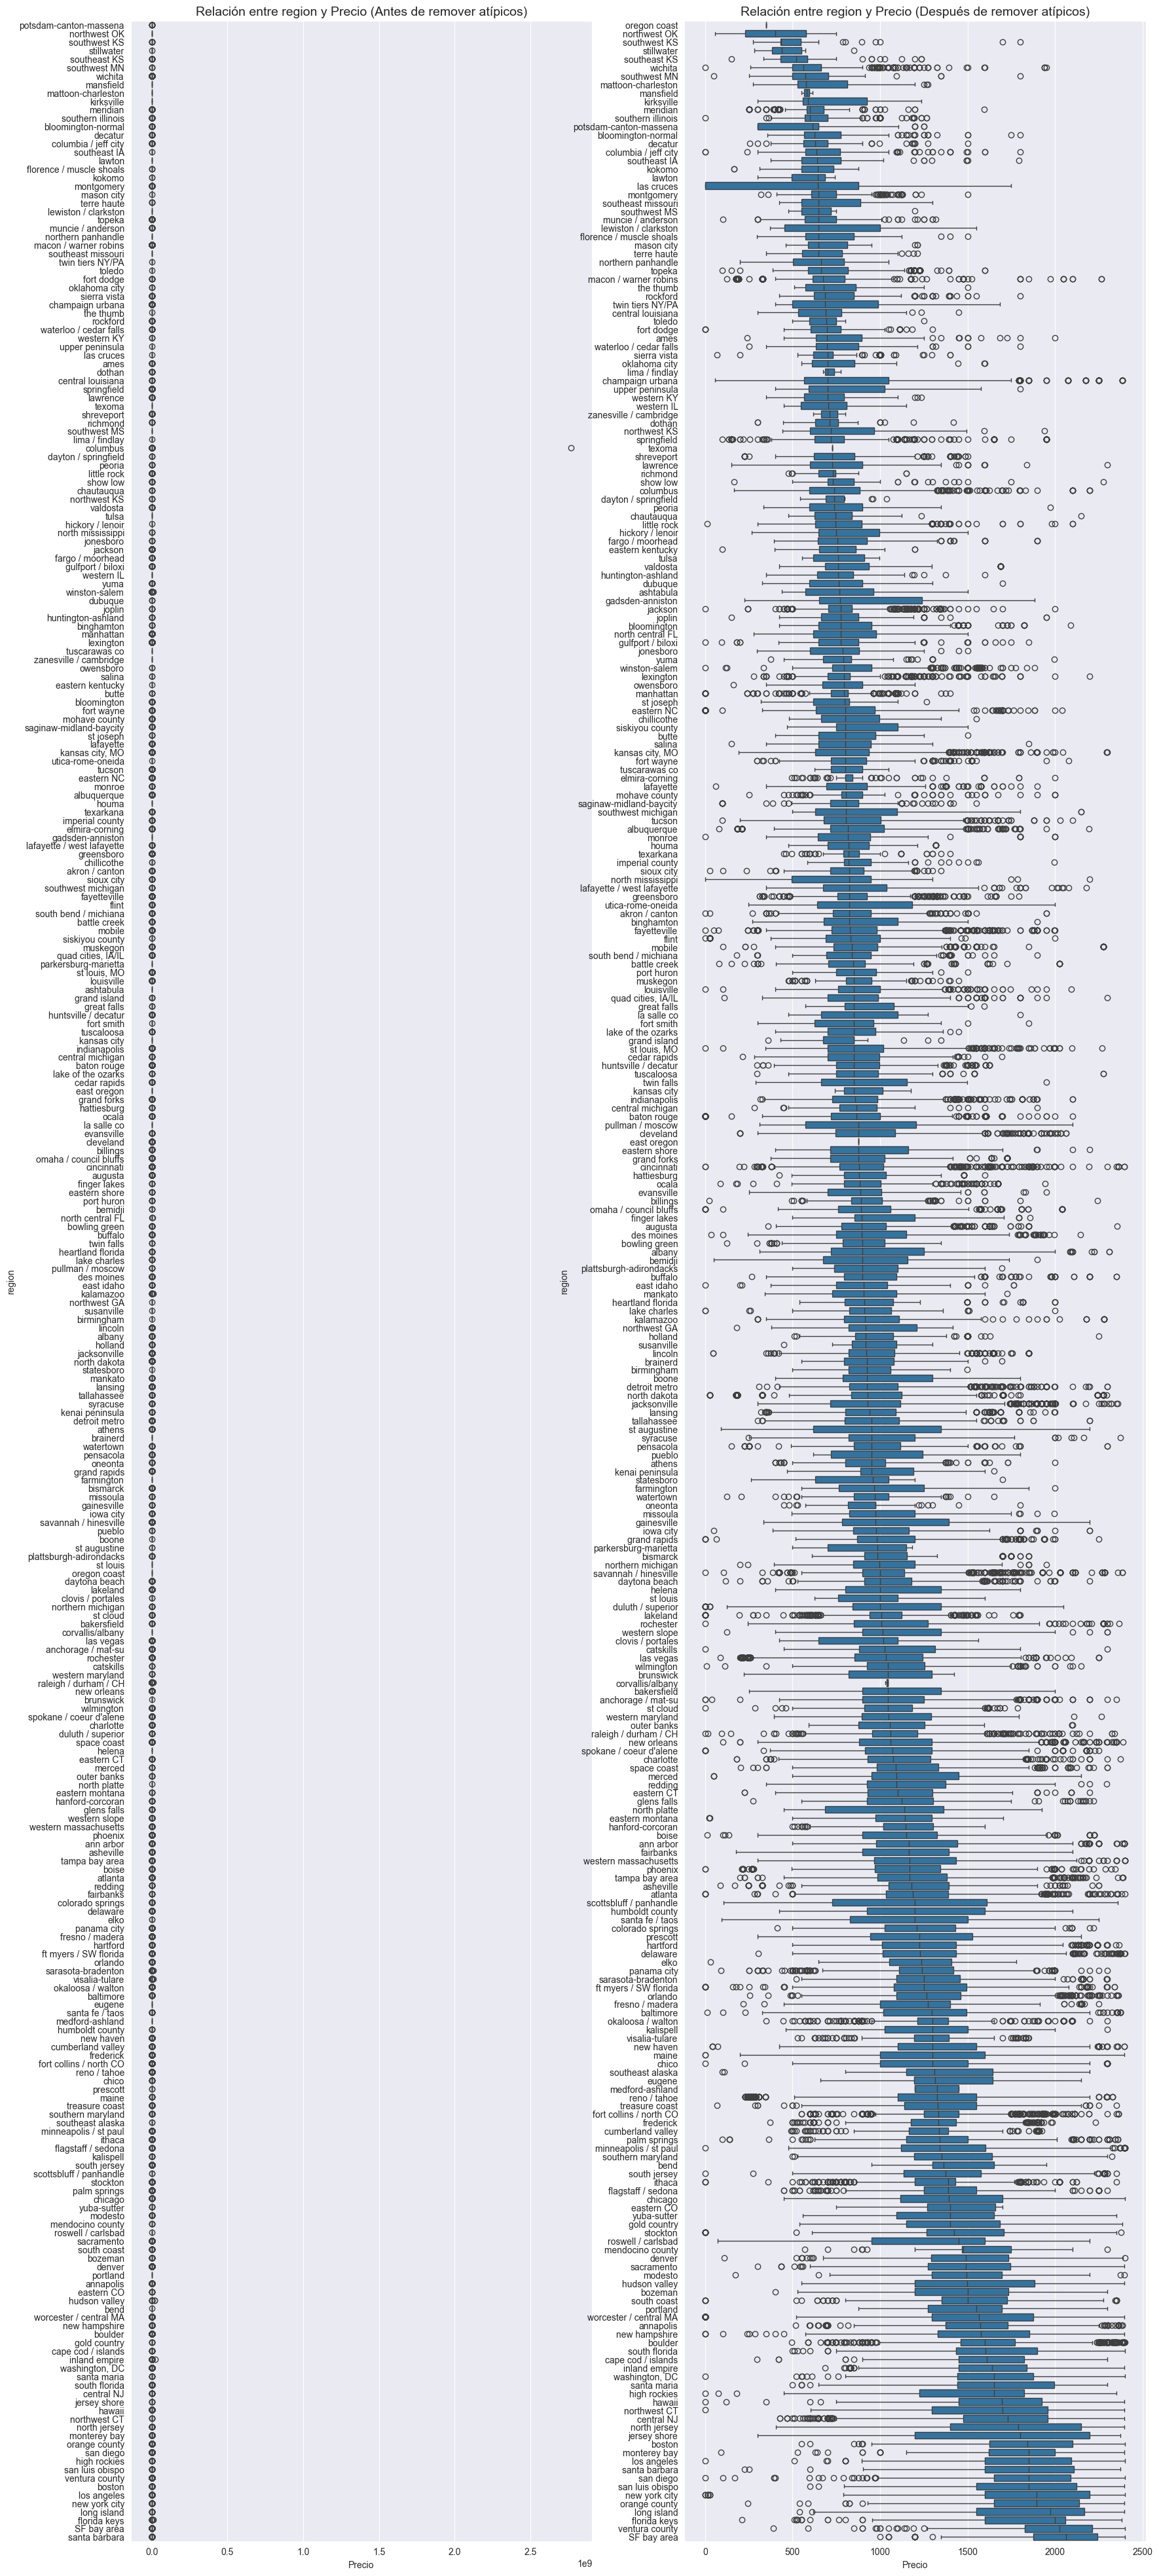

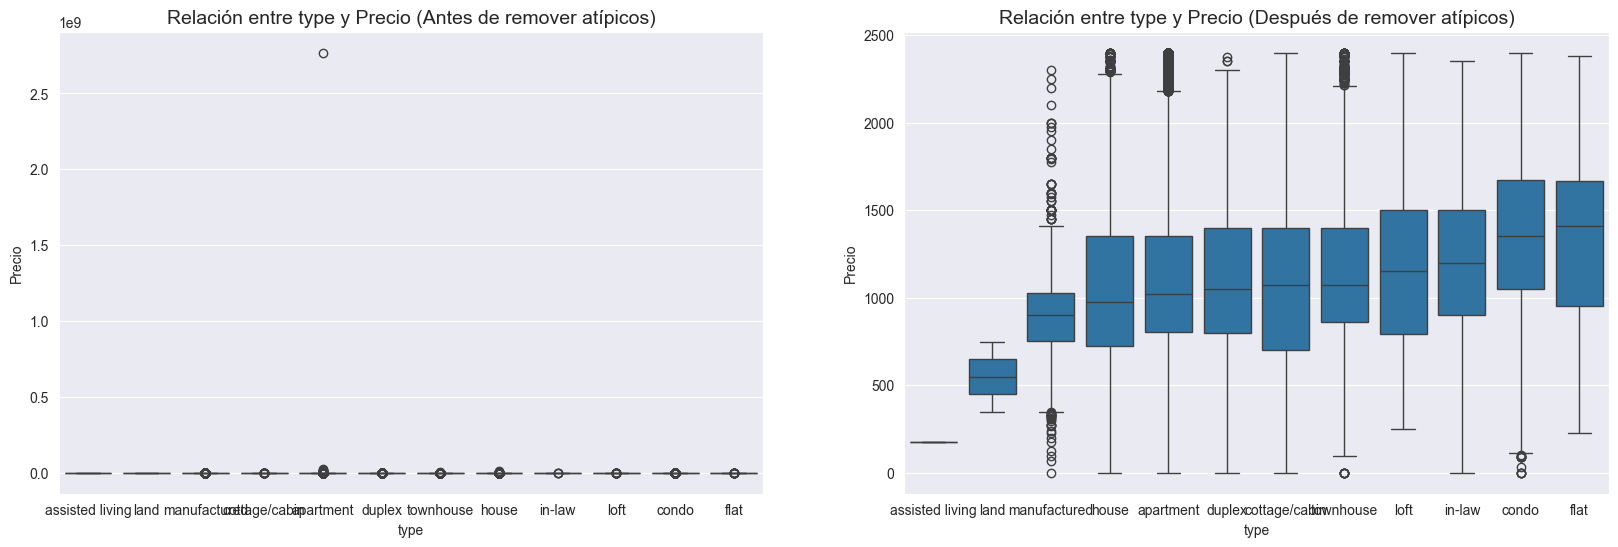

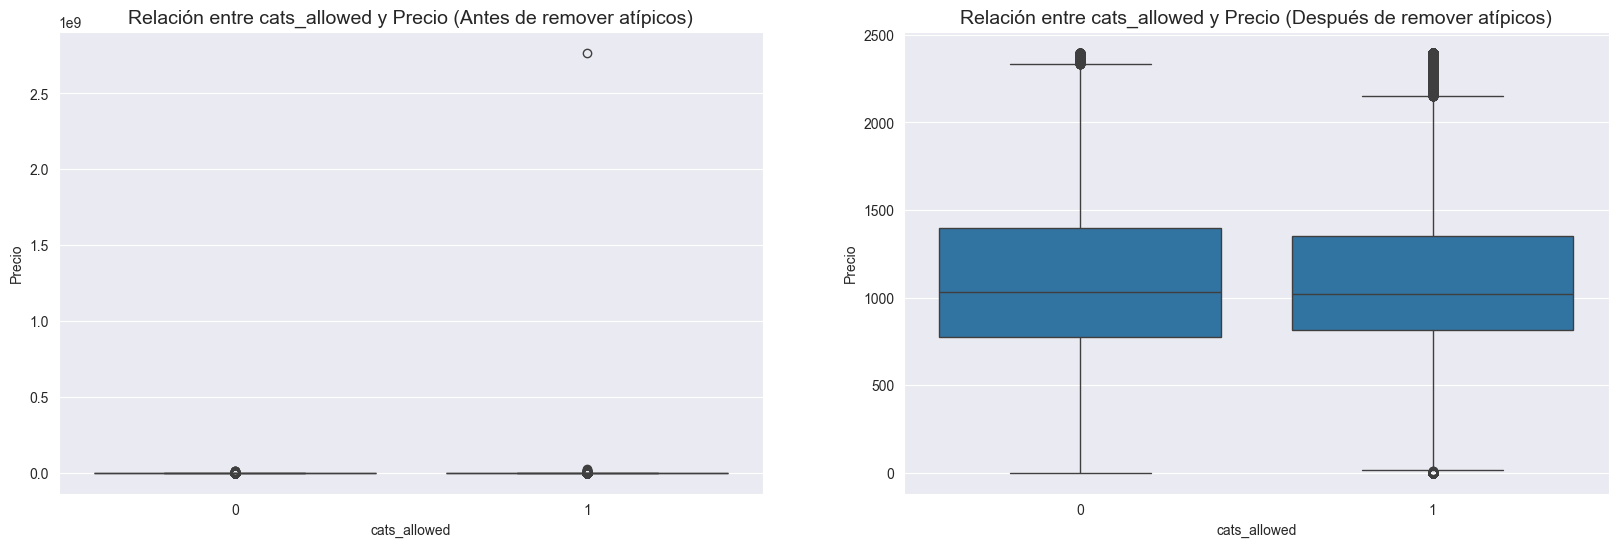

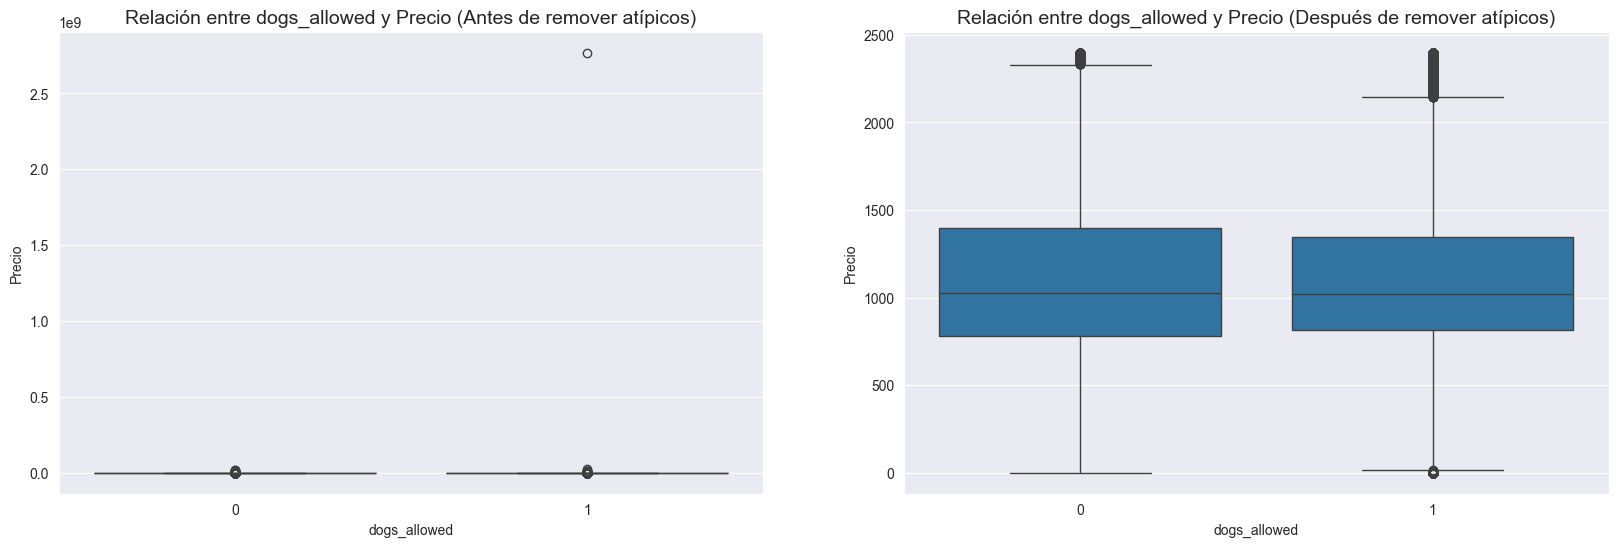

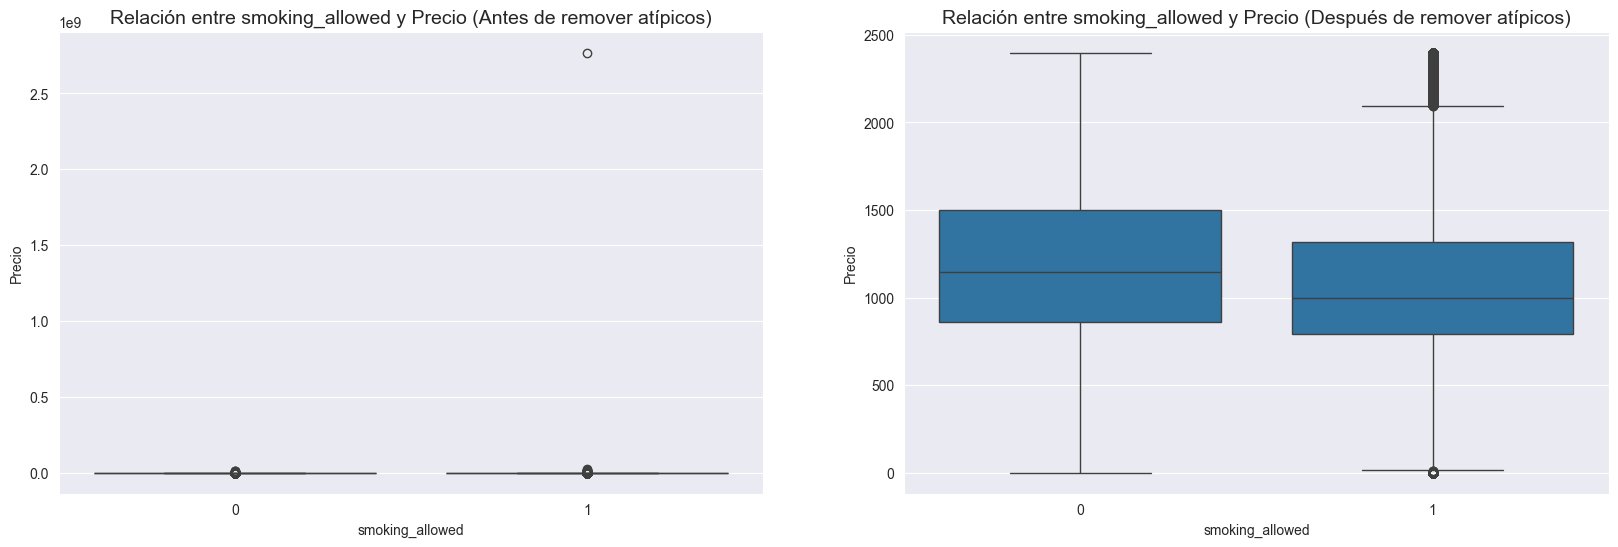

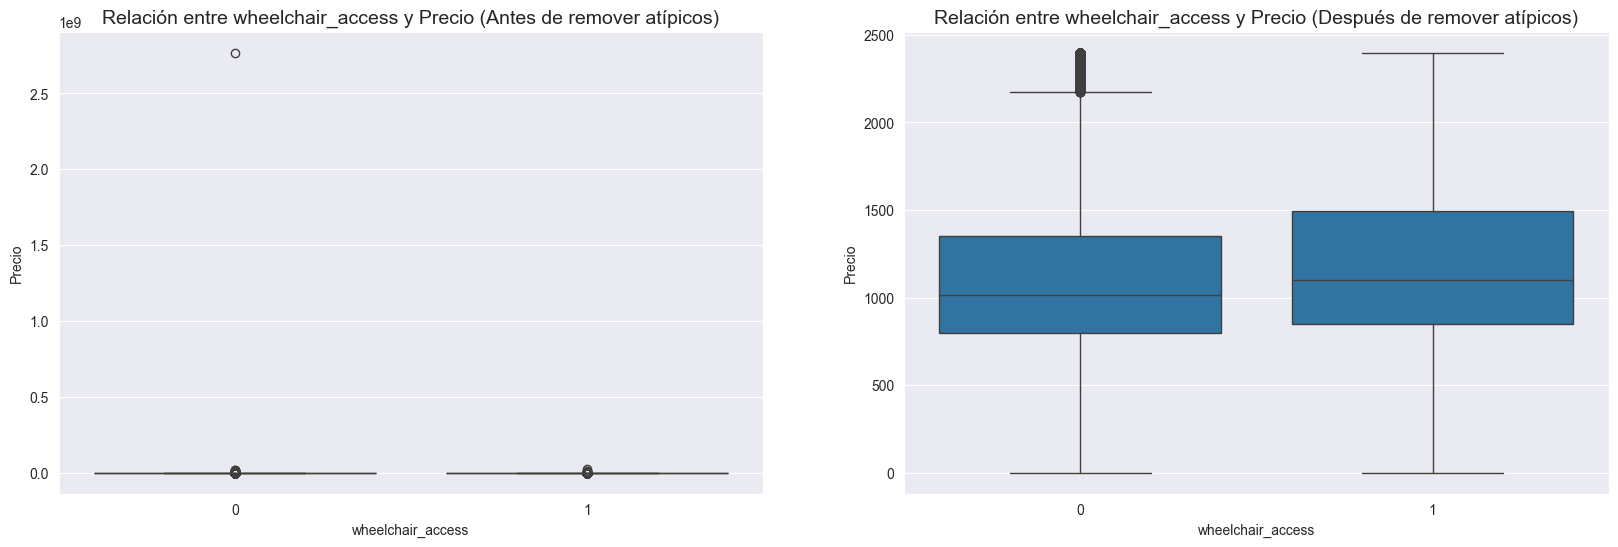

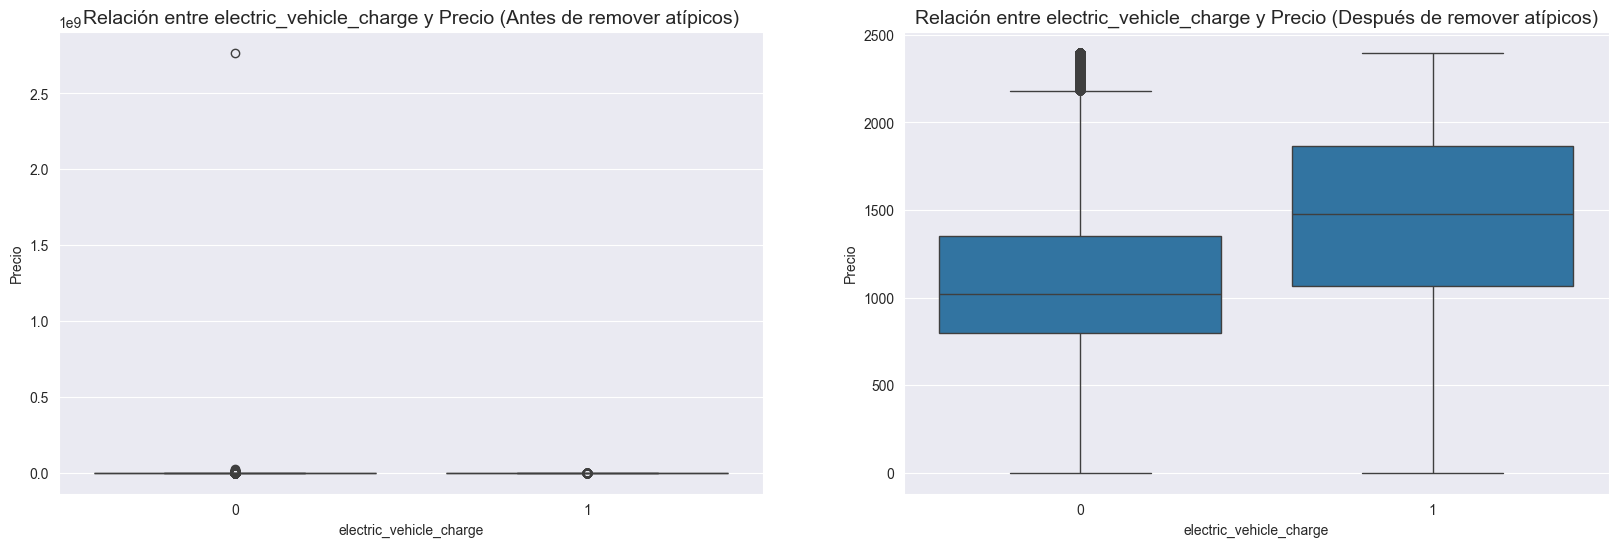

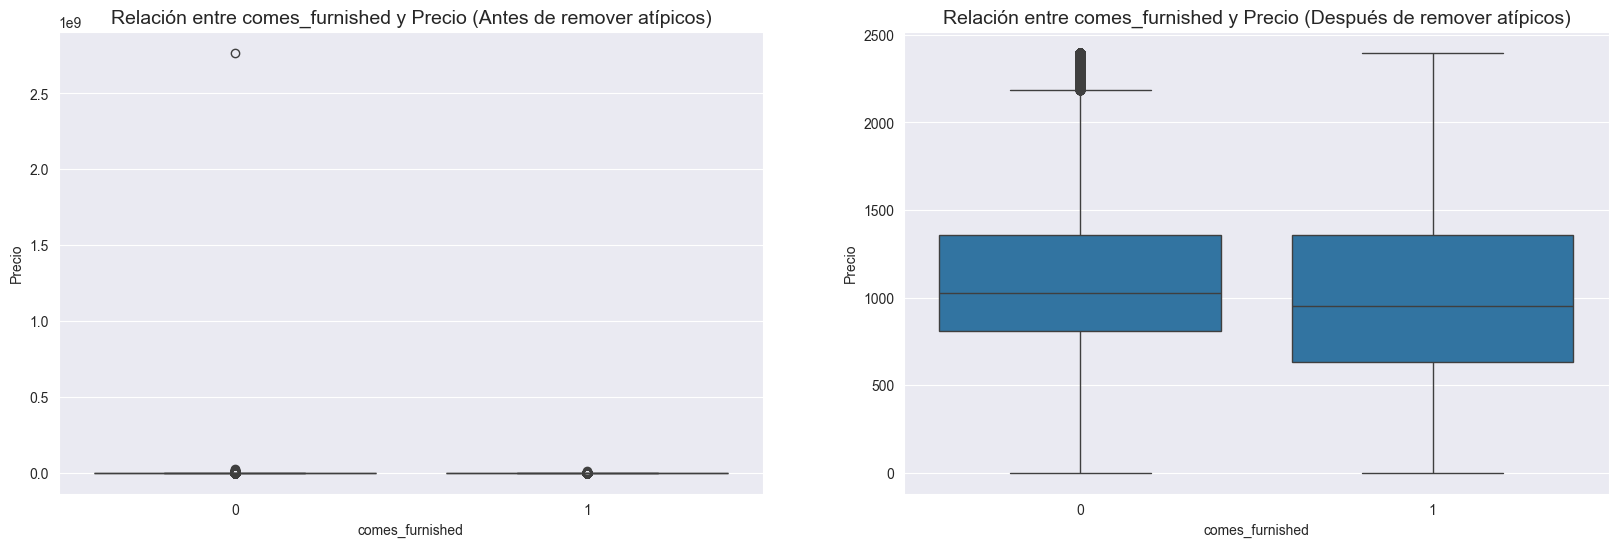

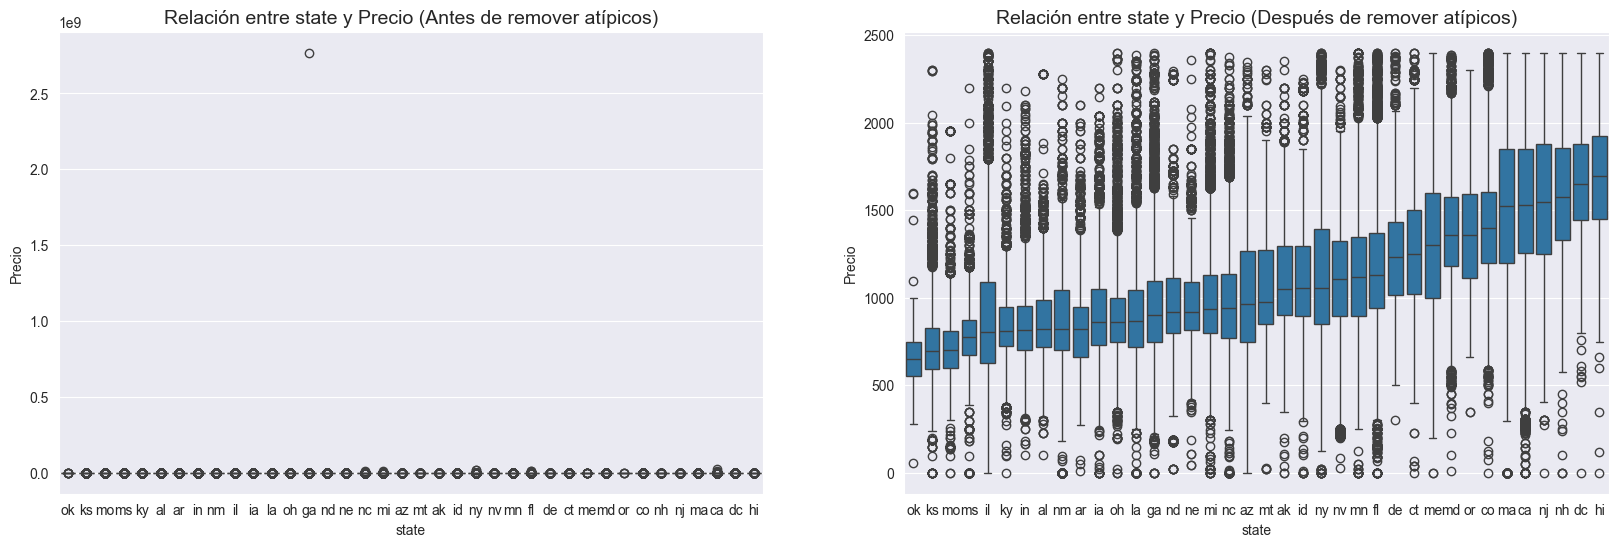

In [159]:
for col in vars_cat:
    if col == "region":
        # Sort regions by median price before plotting
        sorted_regions = data.groupby("region")[target_var_num].median().sort_values()

        plt.figure(figsize=(20, 50))  # Larger figure for better readability
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, y=col, x=target_var_num, order=sorted_regions.index)  # Vertical & sorted
        plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
        plt.xlabel('Precio')
        plt.ylabel(col)

        plt.subplot(1, 2, 2)
        sorted_regions_cleaned = data_cleaned.groupby("region")[target_var_num].median().sort_values()
        sns.boxplot(data=data_cleaned, y=col, x=target_var_num, order=sorted_regions_cleaned.index)  # Vertical & sorted
        plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
        plt.xlabel('Precio')
        plt.ylabel(col)
        plt.show()

    elif col in ["type", "state"]:  # Sort "type" and "state" by median price
        sorted_categories = data.groupby(col)[target_var_num].median().sort_values()

        plt.figure(figsize=(20, 6))
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=col, y=target_var_num, order=sorted_categories.index)  # Horizontal & sorted
        plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')

        sorted_categories_cleaned = data_cleaned.groupby(col)[target_var_num].median().sort_values()
        plt.subplot(1, 2, 2)
        sns.boxplot(data=data_cleaned, x=col, y=target_var_num, order=sorted_categories_cleaned.index)  # Horizontal & sorted
        plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')
        plt.show()

    else:
        plt.figure(figsize=(20, 6))  # Standard size for other categories
        plt.subplot(1, 2, 1)
        sns.boxplot(data=data, x=col, y=target_var_num)  # Horizontal plot
        plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')

        plt.subplot(1, 2, 2)
        sns.boxplot(data=data_cleaned, x=col, y=target_var_num)  # Horizontal plot
        plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Precio')
        plt.show()


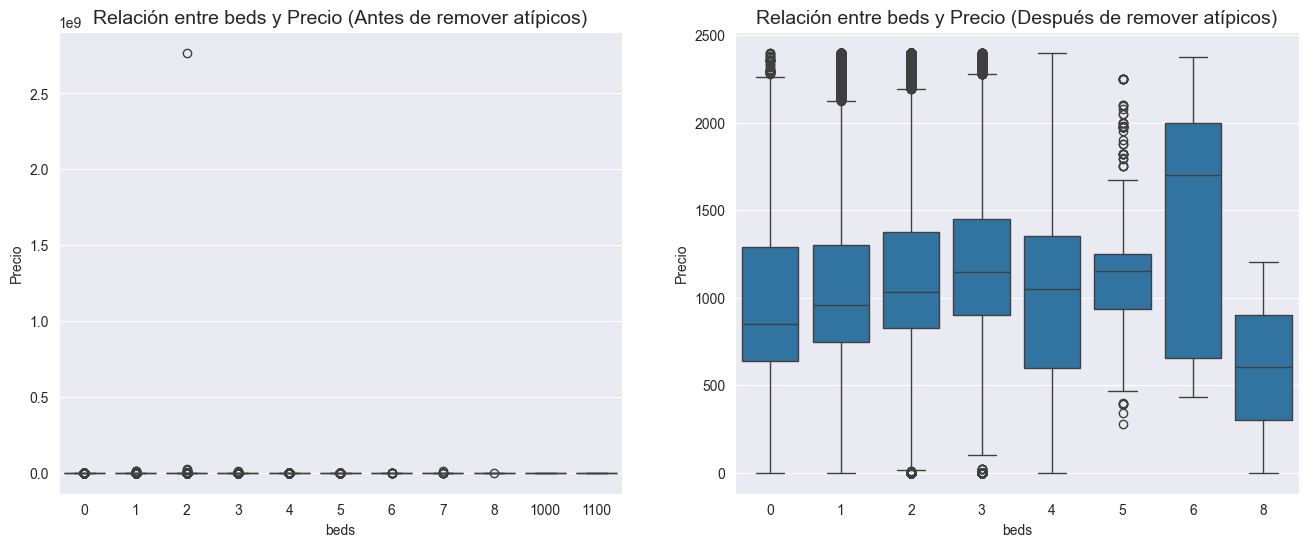

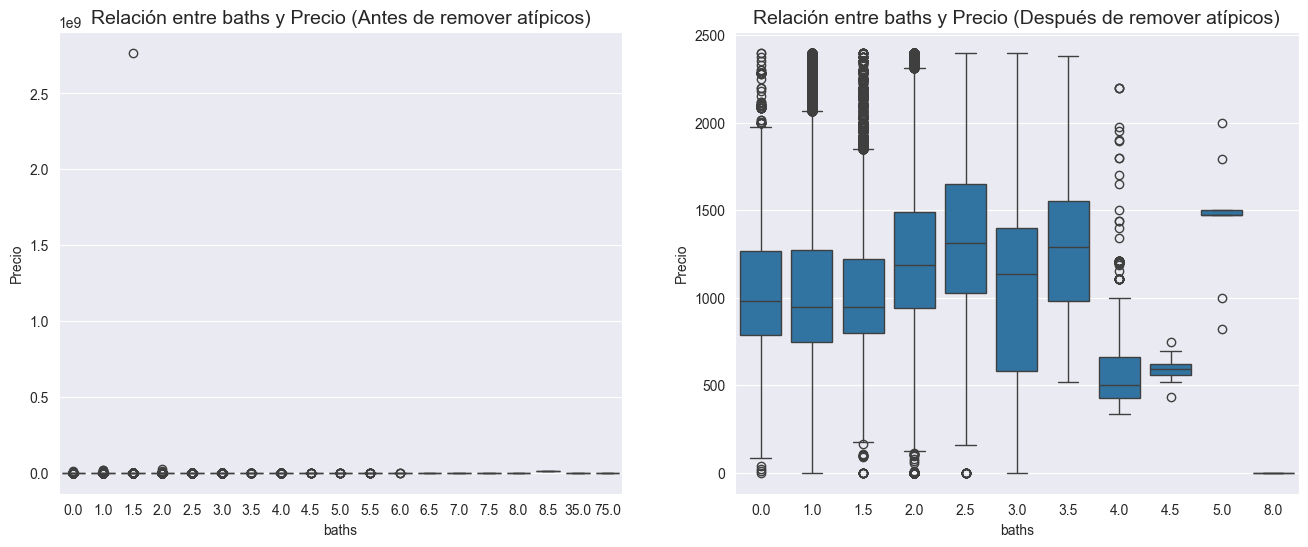

In [146]:
for col in vars_disc:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=data, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=data_cleaned, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()

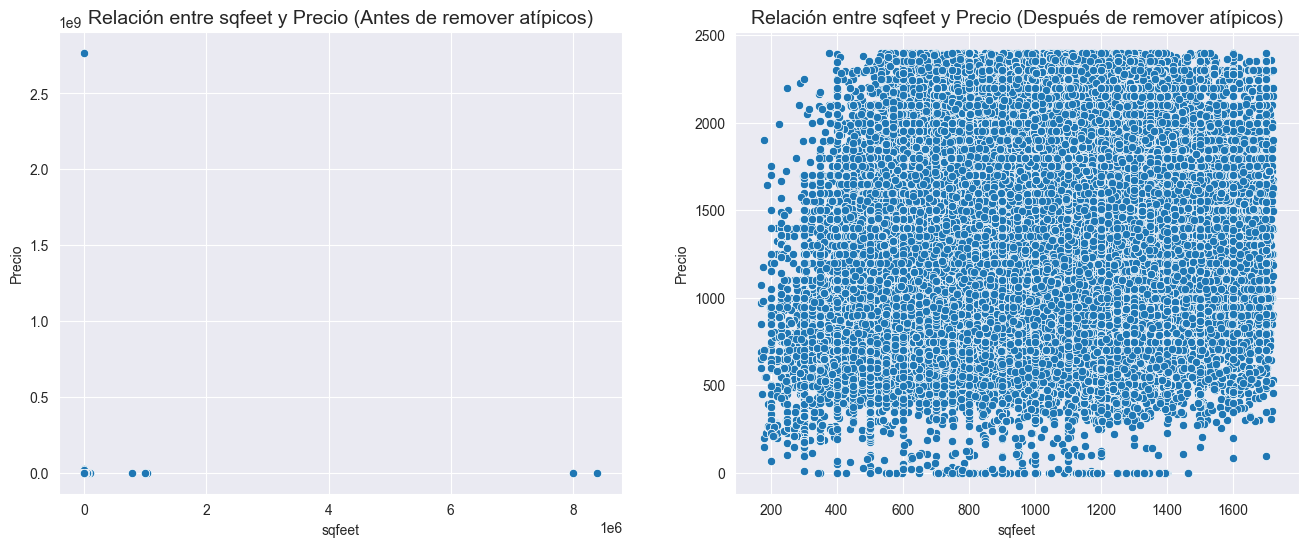

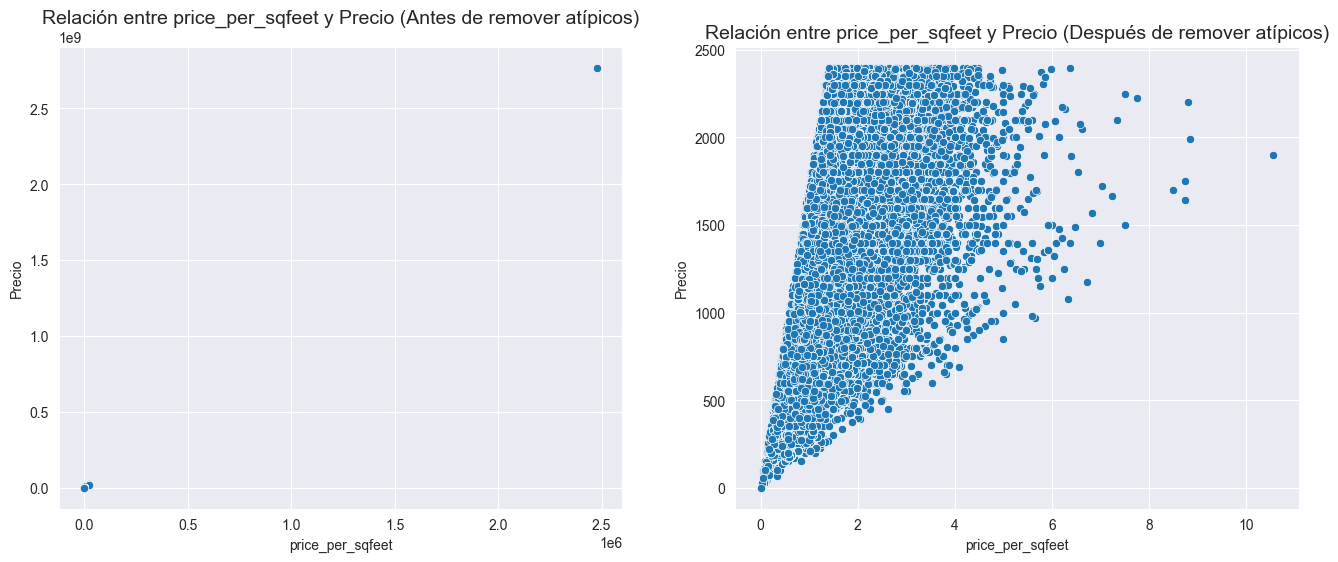

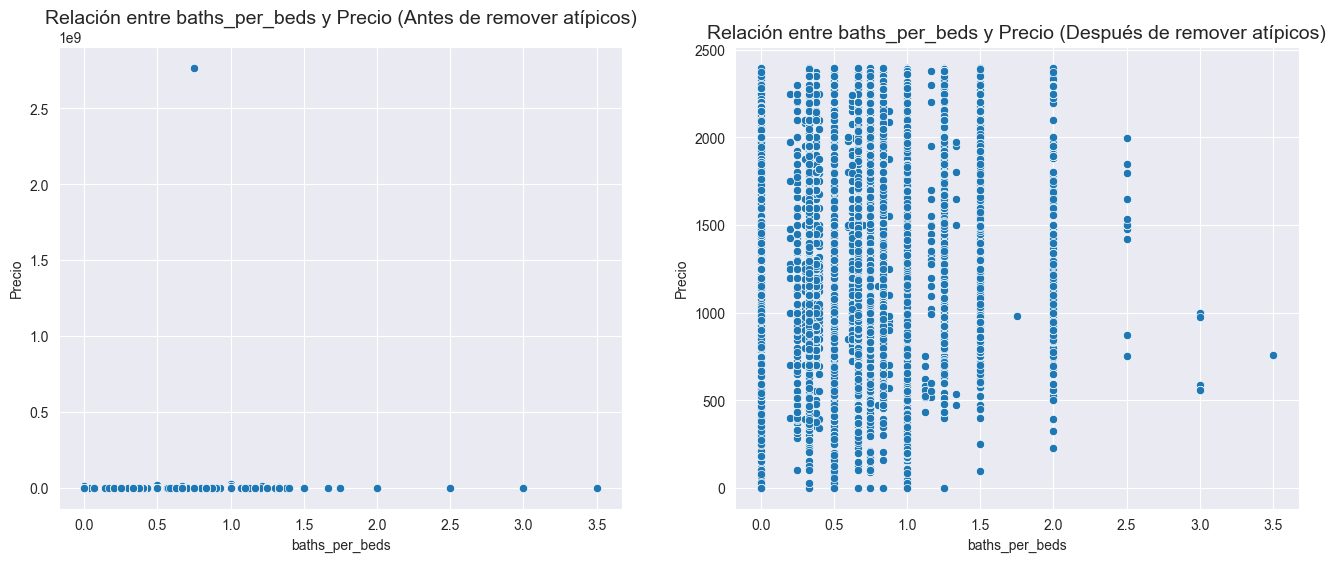

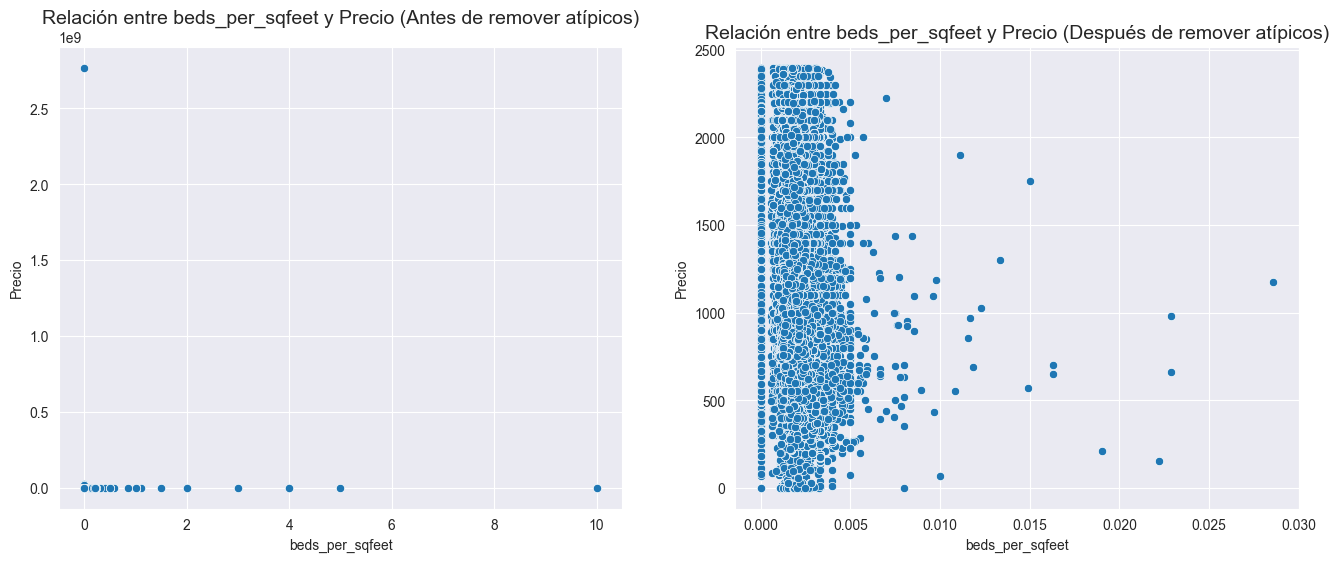

In [147]:
for col in vars_con:
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=data, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Antes de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=data_cleaned, x=col, y=target_var_num)
    plt.title(f'Relación entre {col} y Precio (Después de remover atípicos)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Precio')
    plt.show()


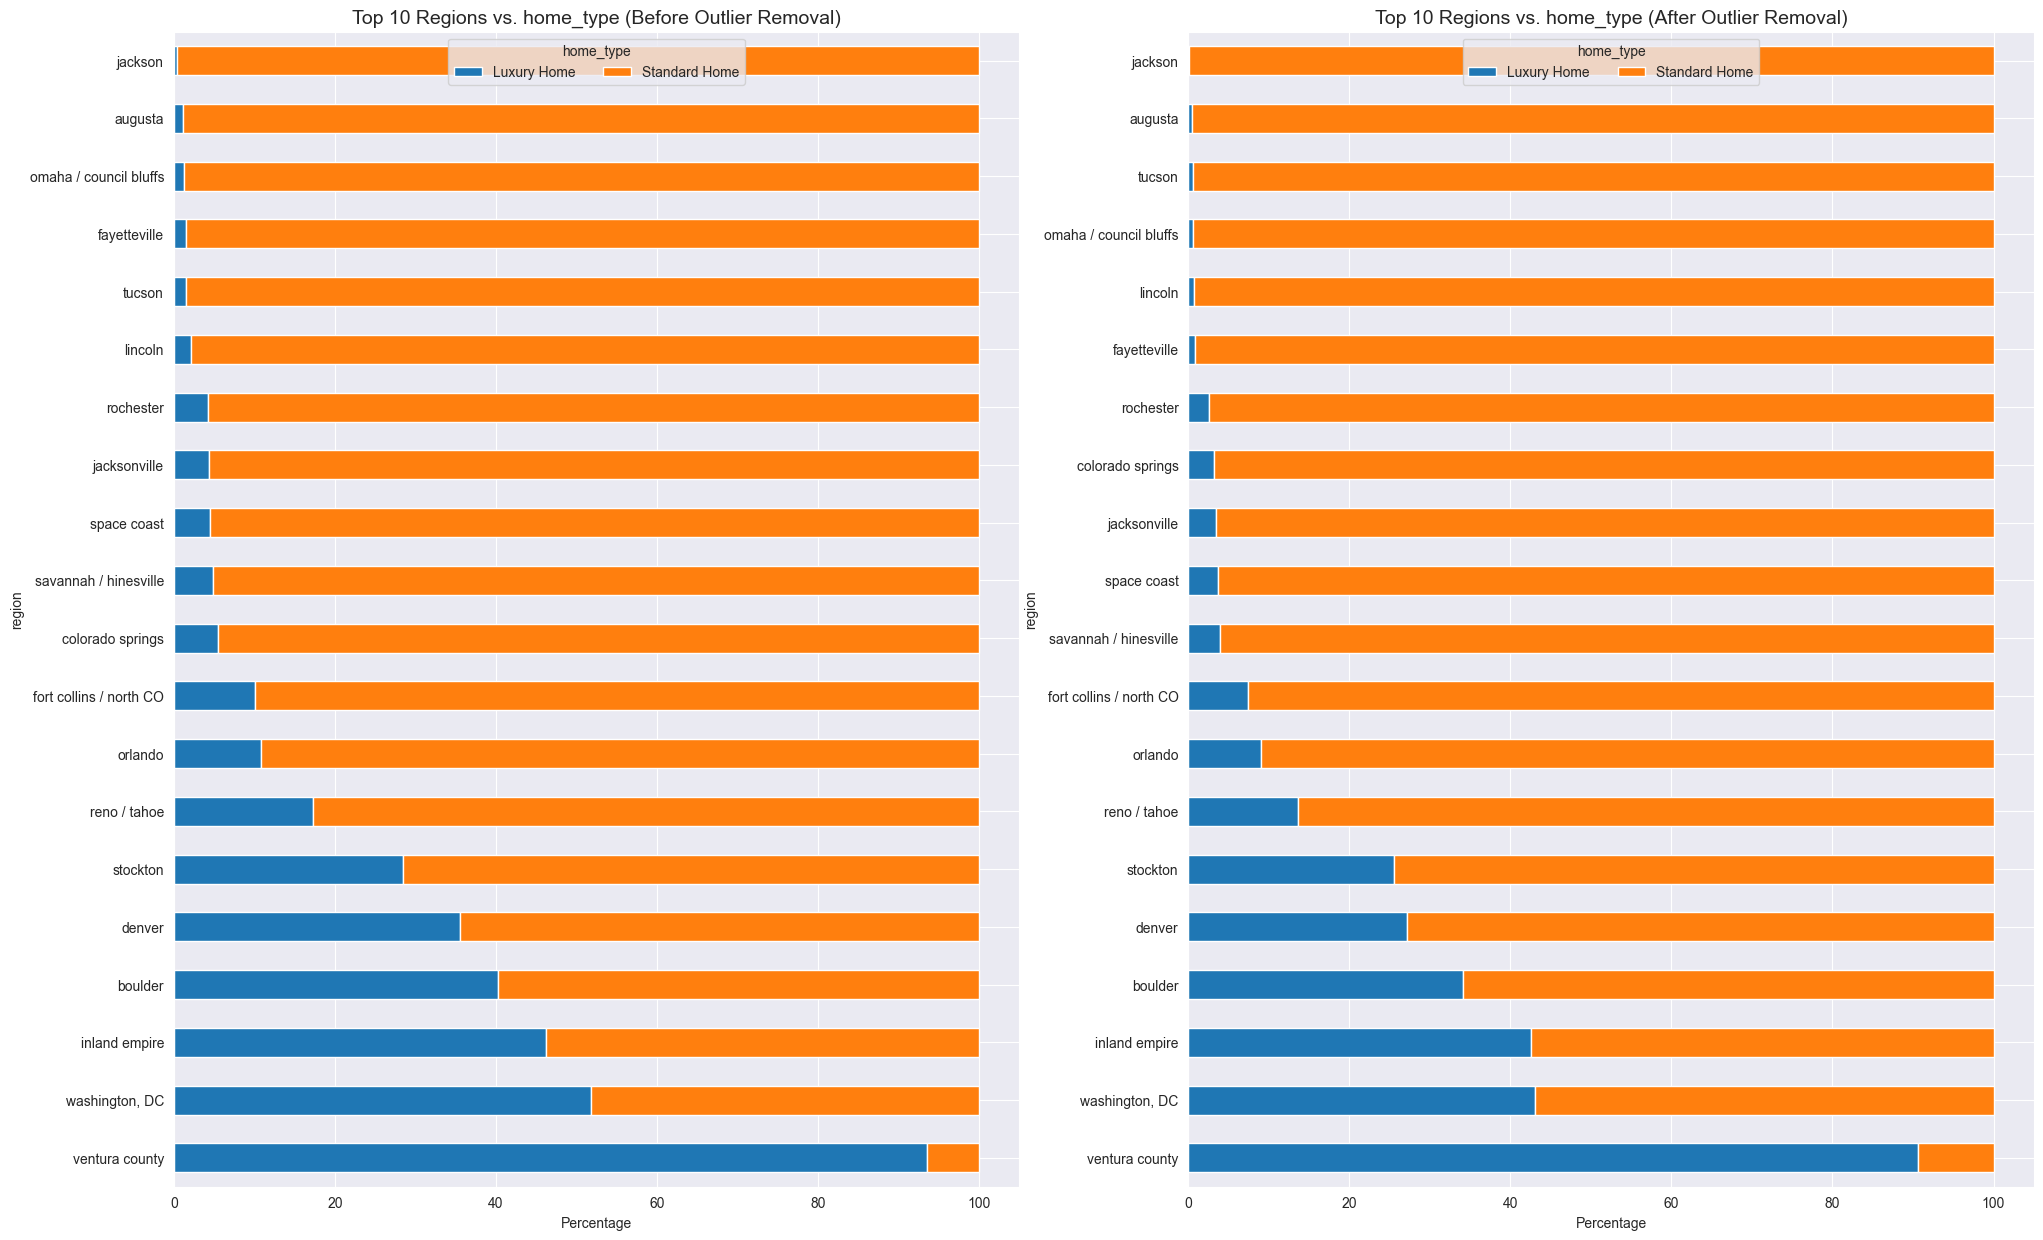

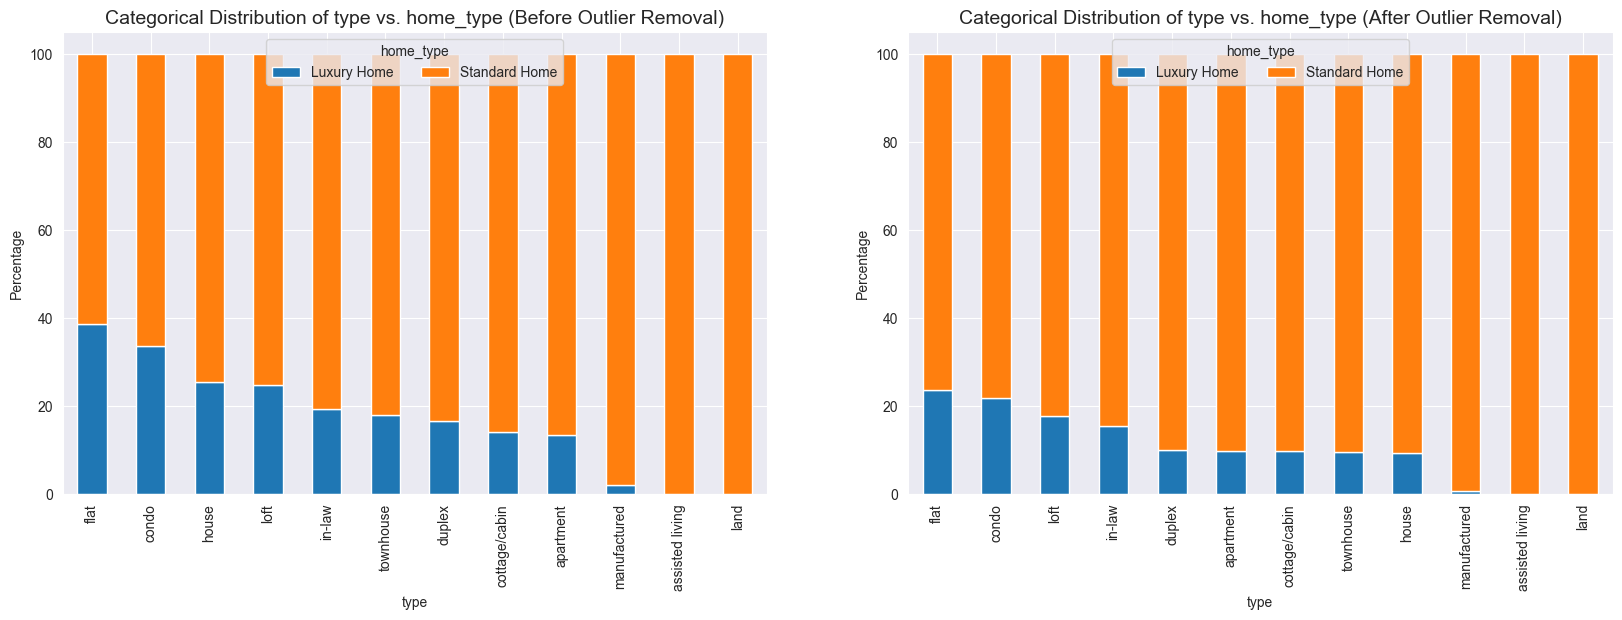

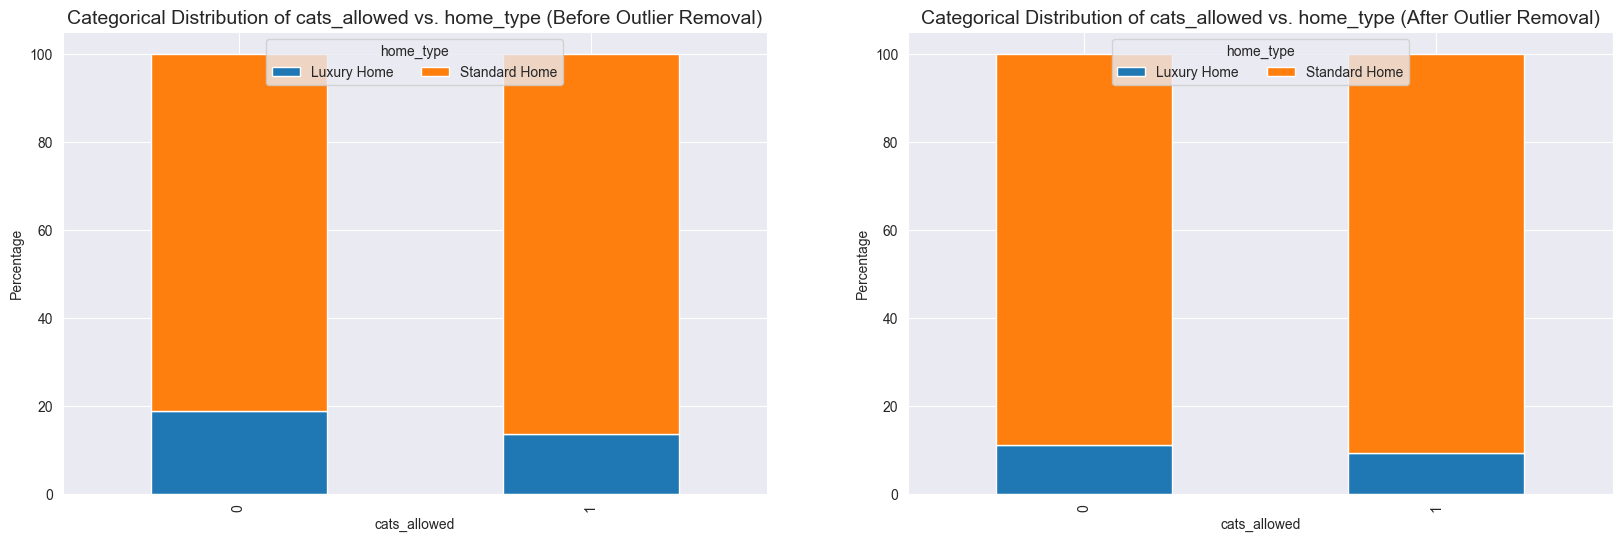

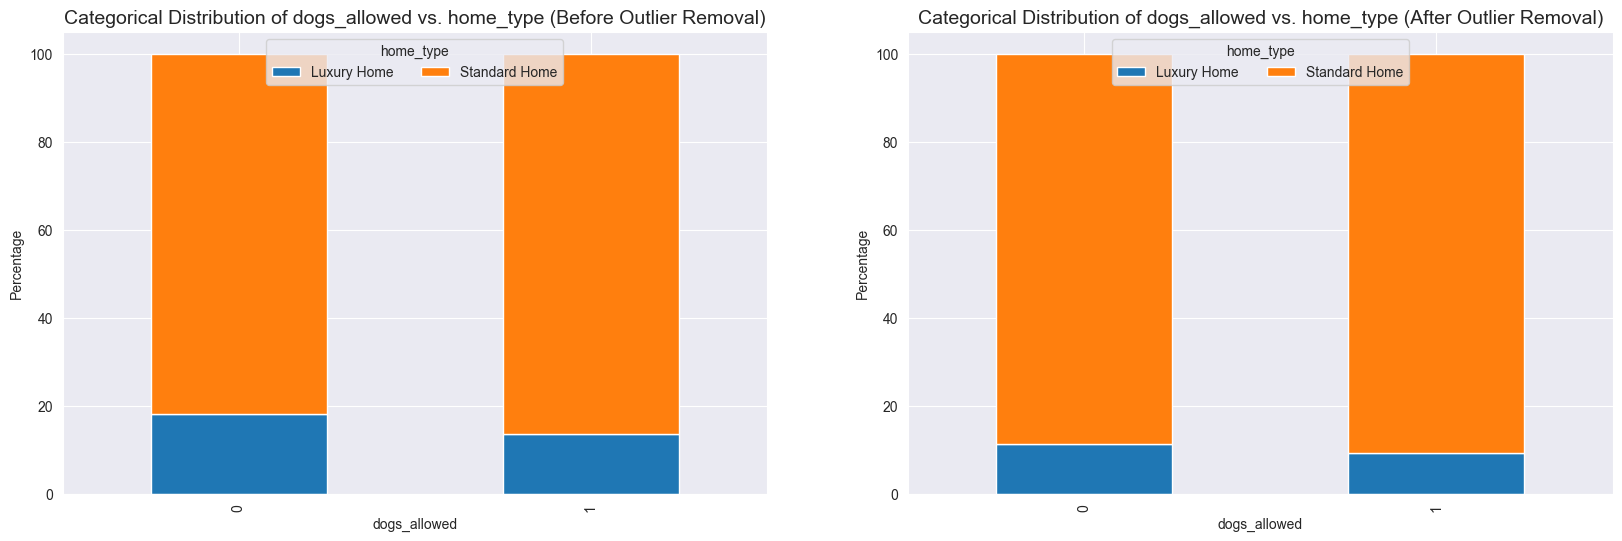

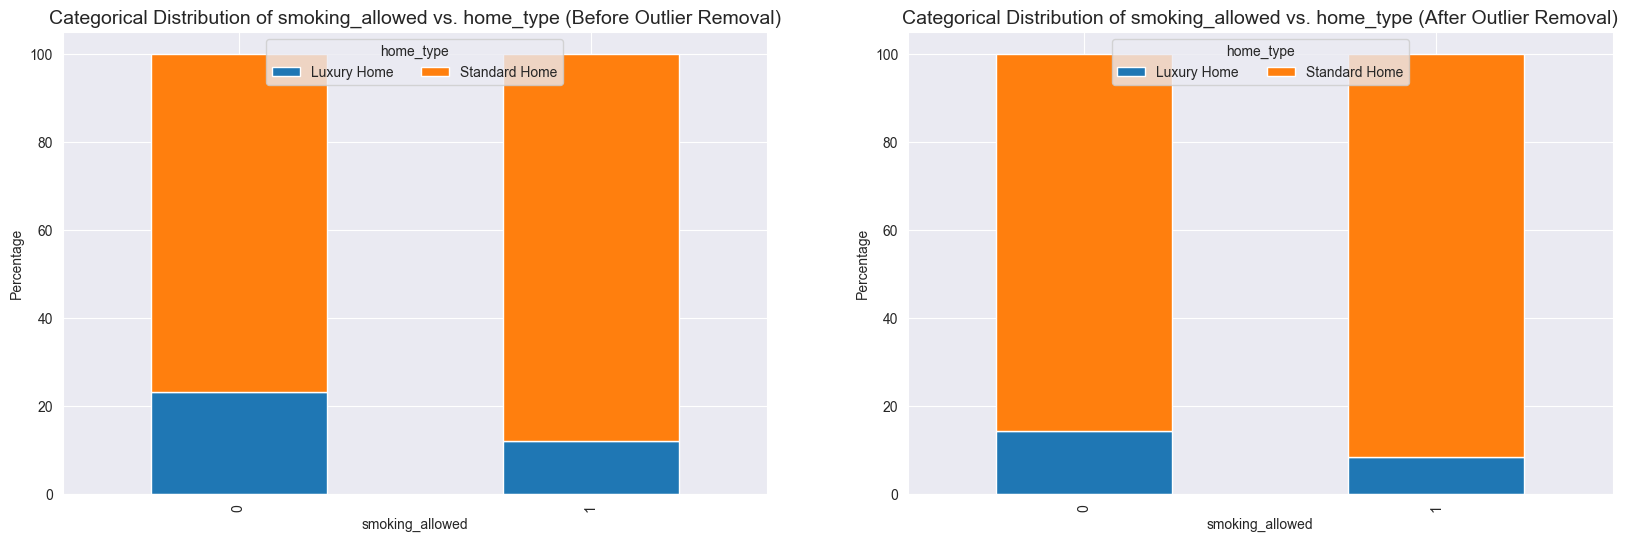

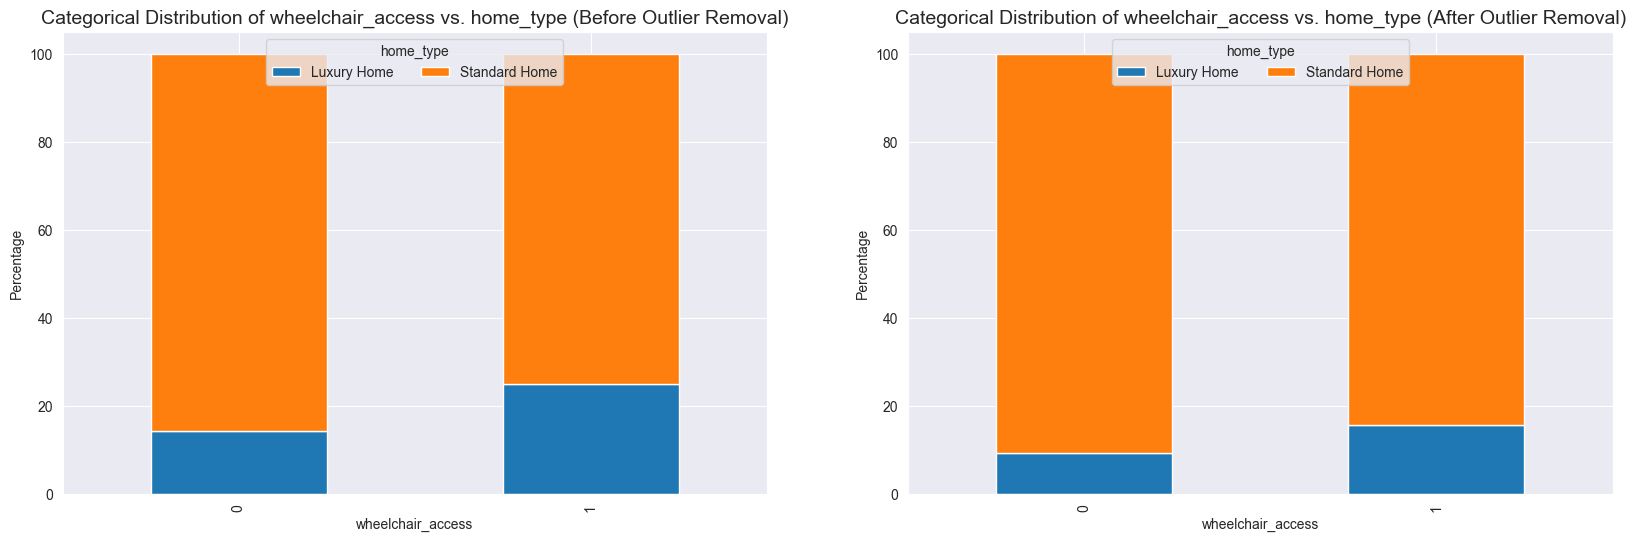

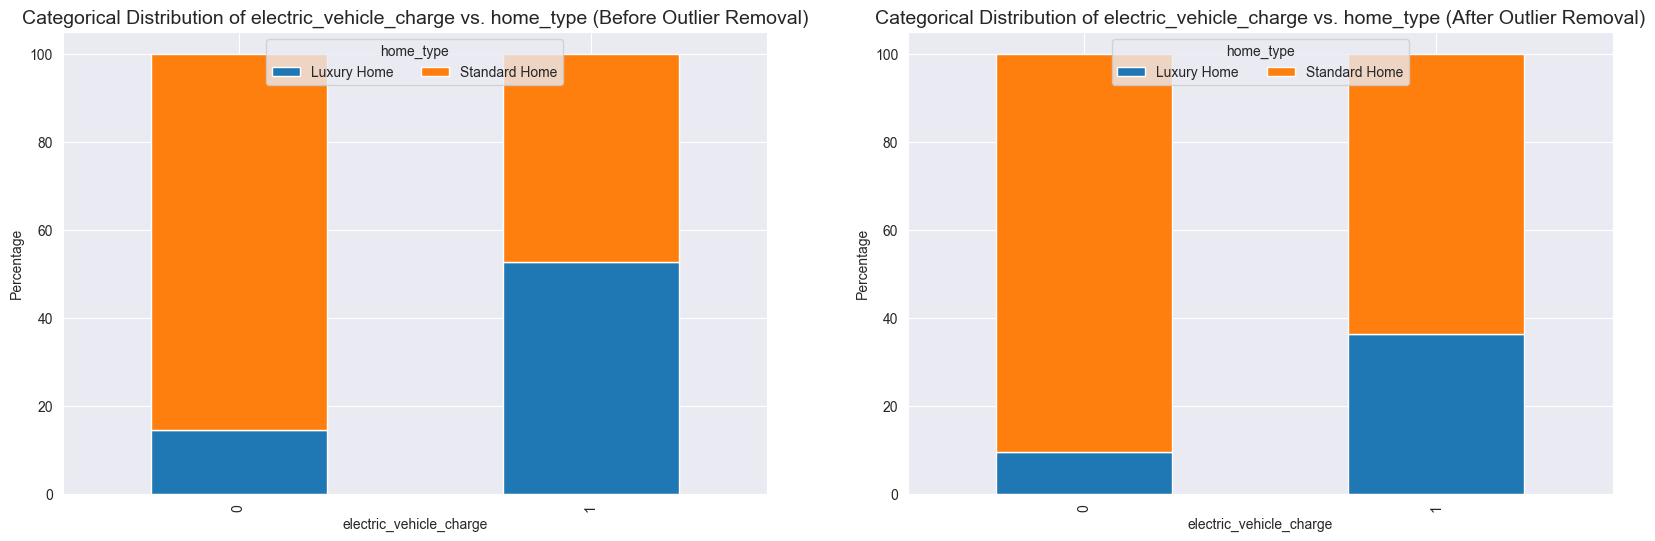

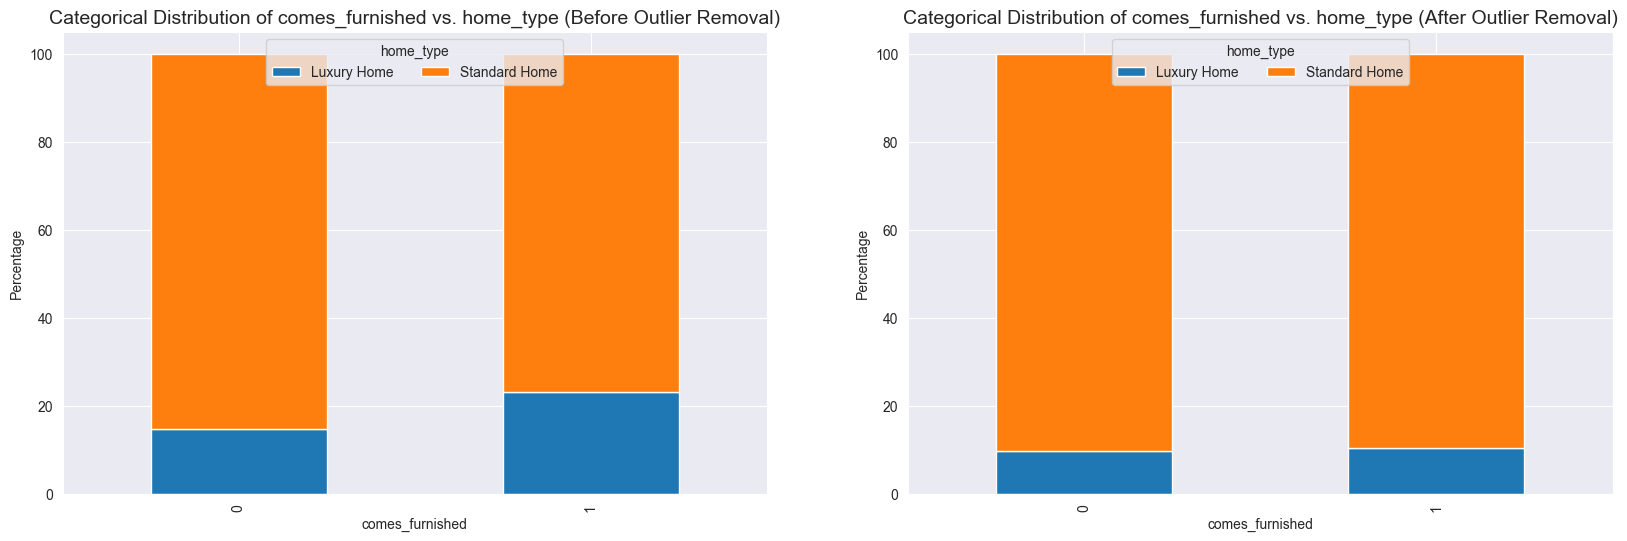

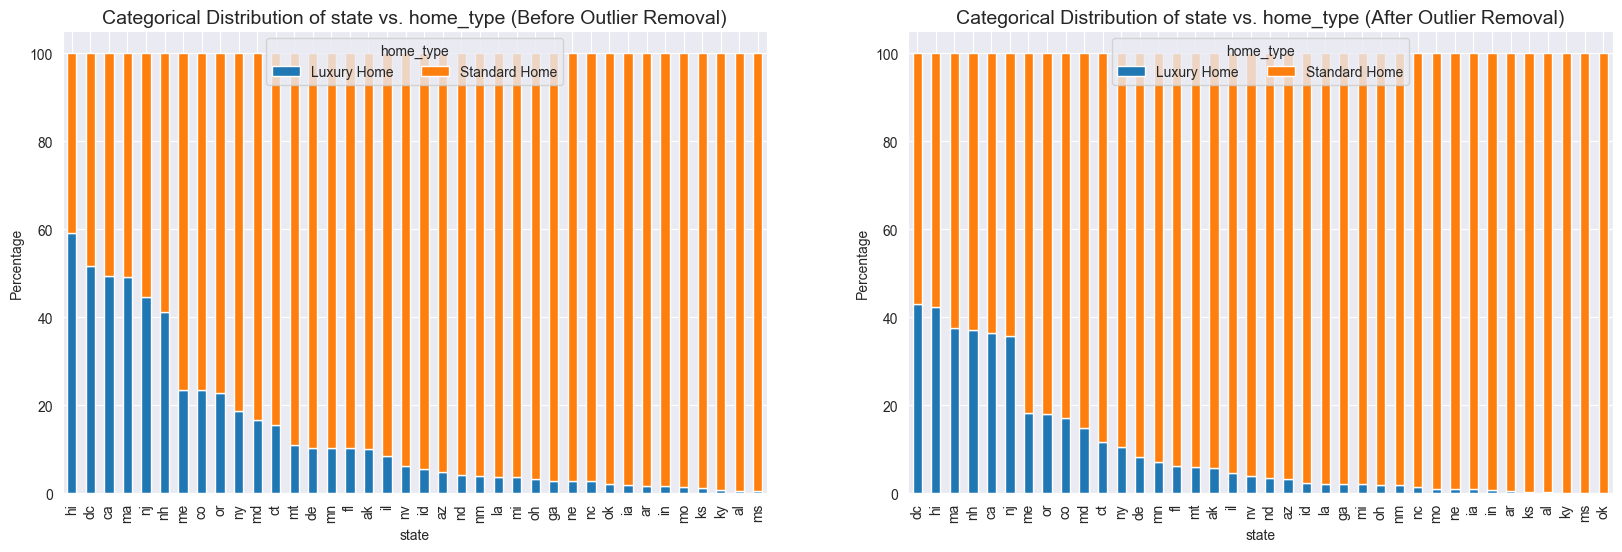

In [145]:
for col in vars_cat:
    if col == "region":
        plt.figure(figsize=(24, 15))  # Adjust height for better visualization

        top_10_regions = data[col].value_counts().nlargest(20).index
        filtered_data = data[data[col].isin(top_10_regions)]
        filtered_data_cleaned = data_cleaned[data_cleaned[col].isin(top_10_regions)]

        # Compute normalized proportions
        region_dist = pd.crosstab(filtered_data[col], filtered_data[target_var_cat], normalize='index') * 100
        region_dist_cleaned = pd.crosstab(filtered_data_cleaned[col], filtered_data_cleaned[target_var_cat], normalize='index') * 100

        # Sort by "Luxury Home" percentage
        if "Luxury Home" in region_dist.columns:
            region_dist = region_dist.sort_values(by="Luxury Home", ascending=False)
        if "Luxury Home" in region_dist_cleaned.columns:
            region_dist_cleaned = region_dist_cleaned.sort_values(by="Luxury Home", ascending=False)

        plt.subplot(1, 2, 1)
        region_dist.plot(kind='barh', stacked=True, ax=plt.gca())
        plt.title(f'Top 10 Regions vs. {target_var_cat} (Before Outlier Removal)', fontsize=14)
        plt.xlabel('Percentage')
        plt.ylabel(col)
        plt.legend(title=target_var_cat, loc='upper center', ncol=3)

        plt.subplot(1, 2, 2)
        region_dist_cleaned.plot(kind='barh', stacked=True, ax=plt.gca())
        plt.title(f'Top 10 Regions vs. {target_var_cat} (After Outlier Removal)', fontsize=14)
        plt.xlabel('Percentage')
        plt.ylabel(col)
        plt.legend(title=target_var_cat,  loc='upper center', ncol=3)

    else:
        plt.figure(figsize=(20, 6))

        # Compute normalized proportions
        cat_dist = pd.crosstab(data[col], data[target_var_cat], normalize='index') * 100
        cat_dist_cleaned = pd.crosstab(data_cleaned[col], data_cleaned[target_var_cat], normalize='index') * 100

        # Sort by "Luxury Home" percentage if applicable
        if col in ["type", "state", "region"] and "Luxury Home" in cat_dist.columns:
            cat_dist = cat_dist.sort_values(by="Luxury Home", ascending=False)
        if col in ["type", "state", "region"] and "Luxury Home" in cat_dist_cleaned.columns:
            cat_dist_cleaned = cat_dist_cleaned.sort_values(by="Luxury Home", ascending=False)

        plt.subplot(1, 2, 1)
        cat_dist.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Categorical Distribution of {col} vs. {target_var_cat} (Before Outlier Removal)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.legend(title=target_var_cat,  loc='upper center', ncol=3)

        plt.subplot(1, 2, 2)
        cat_dist_cleaned.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Categorical Distribution of {col} vs. {target_var_cat} (After Outlier Removal)', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.legend(title=target_var_cat, loc='upper center', ncol=3)





## Paso 11: Análisis multivariado

### Paso 11.1: Análisis de Correlación

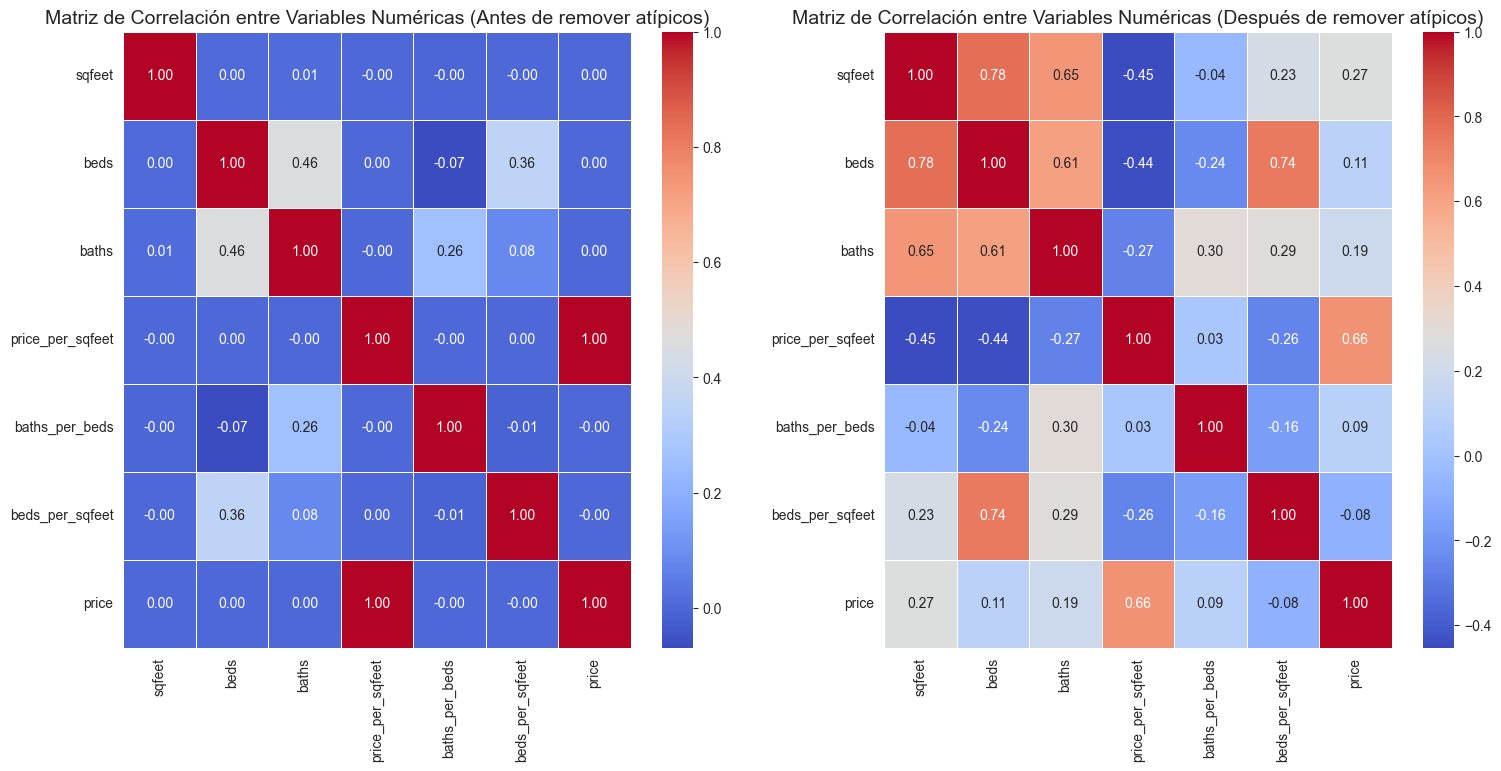

In [45]:
correlation_matrix = data[vars_nums + [target_var_num]].corr()
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Antes de remover atípicos)", fontsize=14)

correlation_matrix_cleaned = data_cleaned[vars_nums + [target_var_num]].corr()
plt.subplot(1, 2, 2)
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas (Después de remover atípicos)", fontsize=14)
plt.show()

## Paso 12: Pruebas de Hipotesis

## Paso 13: Preparación de los Datos

### Paso 13.1: Codificación de Variables Categóricas

In [46]:
df_encoded = data_cleaned.copy()

#### Paso 13.1.1: Aplicar Label Encoding

In [47]:
label_encoder = LabelEncoder()

df_encoded ['home_type'] = label_encoder.fit_transform(data_cleaned['home_type'])

#### Paso 13.1.2: Aplicar one-hot encoding

In [48]:
categorical_columns = ['type', 'state', 'region']
df_encoded = pd.get_dummies(data_cleaned, columns=categorical_columns, drop_first=True)

In [49]:
df_encoded.head()

,price,sqfeet,beds,baths,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished,...,region_western maryland,region_western massachusetts,region_western slope,region_wichita,region_wilmington,region_winston-salem,region_worcester / central MA,region_yuba-sutter,region_yuma,region_zanesville / cambridge
1,1120,1319,3,2.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,825,1133,1,1.5,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,800,927,1,1.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,785,1047,2,1.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,900,1298,2,2.0,1,1,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False


## Paso 14: Organizar los datos en categorías: originales, procesados, regresión y clasificación.

In [50]:
X_original_regression_three_vars = data[['beds', 'baths', 'sqfeet']]
y_original_regression_three_vars = data[target_var_num]

In [51]:
X_processed_regression_three_vars = df_encoded[['beds', 'baths', 'sqfeet']]
y_processed_regression_three_vars = df_encoded[target_var_num]

In [52]:
X_processed_regression_all = df_encoded.drop(columns=['price', 'home_type'], errors='ignore')
y_processed_regression_all = df_encoded[target_var_num]

In [53]:
X_original_classifications = data[['beds', 'baths', 'sqfeet']]
y_original_classification = data[target_var_cat]

In [54]:
X_processed_classification = df_encoded.drop(columns=['price', 'home_type'], errors='ignore')
y_processed_classification = df_encoded[target_var_cat]

In [55]:
X_train_orig_3, X_test_orig_3, y_train_orig_3, y_test_orig_3 = train_test_split(X_original_regression_three_vars,
                                                                                y_original_regression_three_vars,
                                                                                test_size=0.2,
                                                                                random_state=42)
X_train_proc_3, X_test_proc_3, y_train_proc_3, y_test_proc_3 = train_test_split(X_processed_regression_three_vars,
                                                                                y_processed_regression_three_vars,
                                                                                test_size=0.2,
                                                                                random_state=42)
X_train_proc_all, X_test_proc_all, y_train_proc_all, y_test_proc_all = train_test_split(X_processed_regression_all,
                                                                                        y_processed_regression_all,
                                                                                        test_size=0.2,
                                                                                        random_state=42)

In [56]:
X_train_orig_class, X_test_orig_class, y_train_orig_class, y_test_orig_class = train_test_split(X_original_classifications,
                                                                                                y_original_classification,
                                                                                                test_size=0.2,
                                                                                                random_state=42)
X_train_proc_class, X_test_proc_class, y_train_proc_class, y_test_proc_class = train_test_split(X_processed_classification,
                                                                                                y_processed_classification,
                                                                                                test_size=0.2,
                                                                                                random_state=42)

## Paso 15: Función para entrenar, evaluar y graficar modelos

In [57]:
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, title):
    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Cálculo de métricas
    metrics = {
        "MAE_Train": mean_absolute_error(y_train, y_pred_train),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2_Train": r2_score(y_train, y_pred_train),
        "MAE_Test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2_Test": r2_score(y_test, y_pred_test)
    }

    return  y_pred_train, y_pred_test, title, metrics

## Paso 16: Modelos

## Paso 16.1: Modelos para regressión

In [58]:
# --------------------------------------------
# 2. Modelos y Evaluación
# --------------------------------------------

lineal_models = {
    "Regresión Lineal Múltiple": LinearRegression(),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0)
}

lineal_results = []


## Paso 16.2: Modelos para clasificación

In [59]:
logistic_orig_model = LogisticRegression()
logistic_proc_model = LogisticRegression()

## Paso 17: Entrenamiento

### Paos 17.1: Entrenamiento de los modelos de regresión

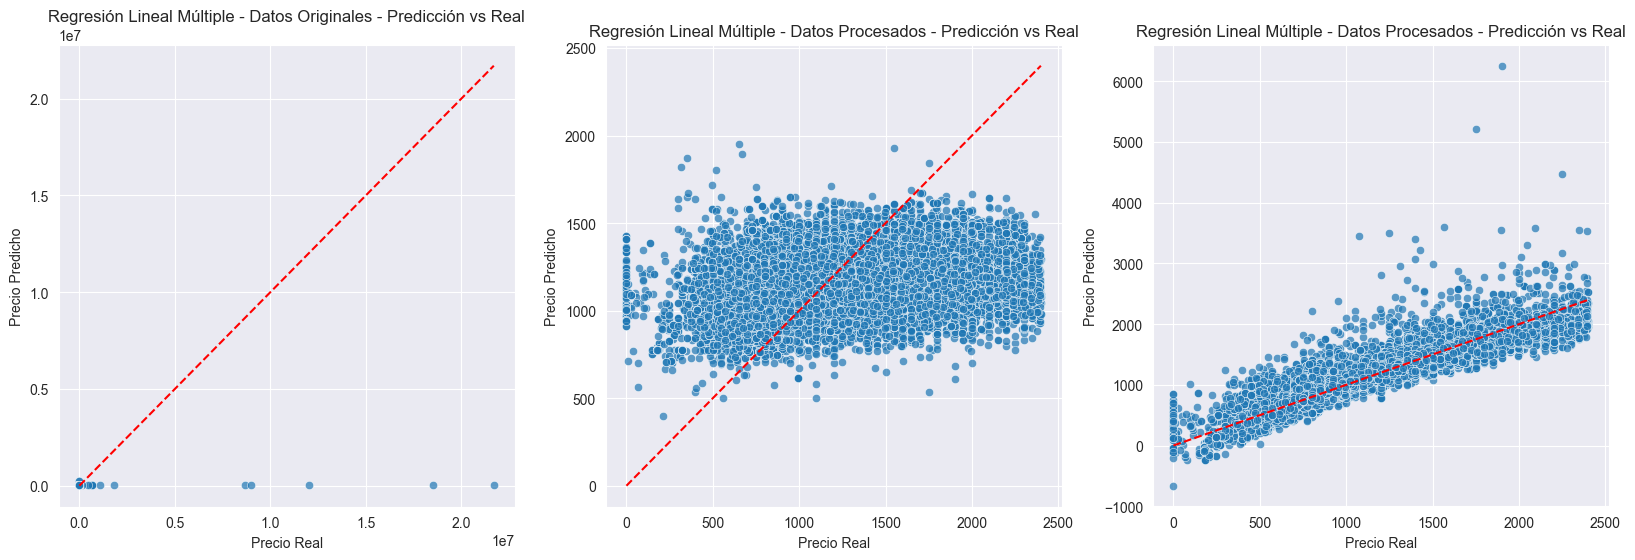

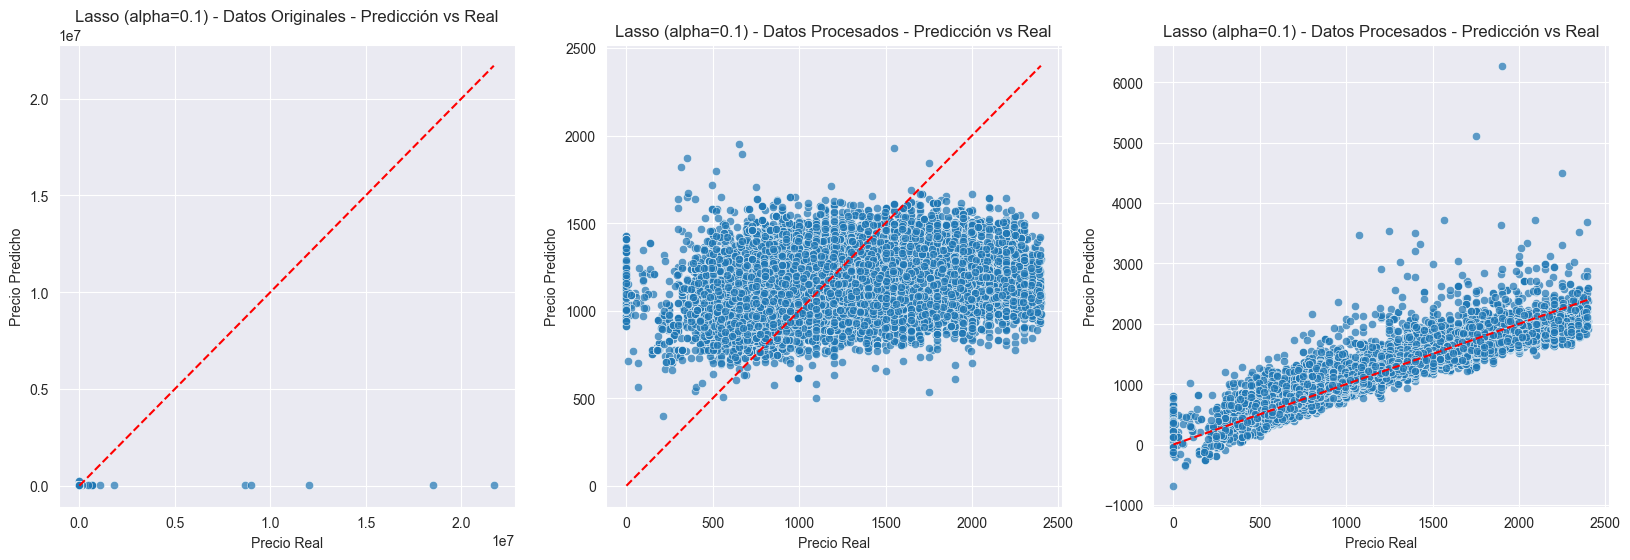

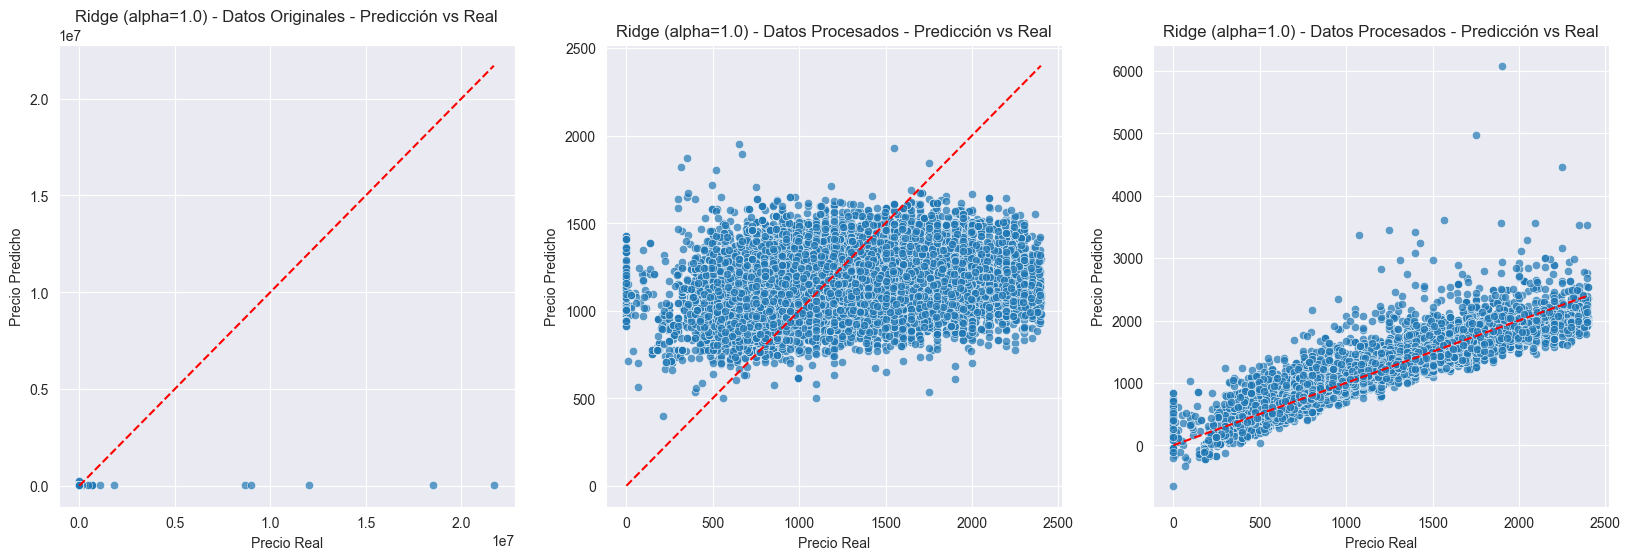

In [60]:
# Entrenamiento y evaluación con la base original
for name, model in lineal_models.items():
    y_train, y_pred_test, title, metrics1 = train_and_evaluate_model(model, X_train_orig_3, X_test_orig_3, y_train_orig_3, y_test_orig_3, f"{name} - Datos Originales")
    lineal_results .append({"Modelo": name + " - Original", **metrics1})
    plt.figure(figsize=(20, 6))
    plt.subplot(1, 3, 1)
    sns.scatterplot(x = y_test_orig_3, y = y_pred_test, alpha = 0.7)
    plt.plot([y_test_orig_3.min(), y_test_orig_3.max()], [y_test_orig_3.min(), y_test_orig_3.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")


    y_train, y_pred_test ,title, metrics2 = train_and_evaluate_model(model, X_train_proc_3, X_test_proc_3, y_train_proc_3, y_test_proc_3, f"{name} - Datos Procesados")
    lineal_results .append({"Modelo": name + " - Procesado 3 Variables", **metrics2})
    plt.subplot(1, 3, 2)
    sns.scatterplot(x=y_test_proc_3, y=y_pred_test, alpha=0.7)
    plt.plot([y_test_proc_3.min(), y_test_proc_3.max()], [y_test_proc_3.min(), y_test_proc_3.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")



    y_train, y_pred_test ,title, metrics3 = train_and_evaluate_model(model, X_train_proc_all, X_test_proc_all, y_train_proc_all, y_test_proc_all, f"{name} - Datos Procesados")
    lineal_results.append({"Modelo": name + " - Procesado Todas Variables", **metrics3})
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=y_test_proc_all, y=y_pred_test, alpha=0.7)
    plt.plot([y_test_proc_all.min(), y_test_proc_all.max()], [y_test_proc_all.min(), y_test_proc_all.max()], '--', color='red')
    plt.xlabel("Precio Real")
    plt.ylabel("Precio Predicho")
    plt.title(f"{title} - Predicción vs Real")
    plt.show()


### Paos 17.2: Entrenamiento de los modelos de clasificación

In [75]:
scaler = StandardScaler()

### Paso 17.2.1 Entrenamiento con Datos Originales

In [76]:
X_train_orig_scaled = scaler.fit_transform(X_train_orig_class)
X_test_orig_scaled = scaler.transform(X_test_orig_class)

In [77]:
logistic_orig_model.fit(X_train_orig_scaled, y_train_orig_class)

LogisticRegression()

In [78]:
y_pred_orig = logistic_orig_model.predict(X_test_orig_scaled)

### 17.2.2 Entrenamiento con Datos Procesados

In [79]:
X_train_proc_scaled = scaler.fit_transform(X_train_proc_class)
X_test_proc_scaled = scaler.transform(X_test_proc_class)

In [80]:
logistic_proc_model.fit(X_train_proc_scaled, y_train_proc_class)

LogisticRegression()

In [81]:
y_pred_proc = logistic_proc_model.predict(X_test_proc_scaled)

## Paso 18: Evaluación

### Paso 18.1: Resultados de regresión

In [82]:
results_df = pd.DataFrame(lineal_results)
results_df

,Modelo,MAE_Train,RMSE_Train,R2_Train,MAE_Test,RMSE_Test,R2_Test
0,Regresión Lineal Múltiple - Original,26874.288492,6.010491e+06,1.026760e-08,14908.551004,145877.138442,-0.006814
1,Regresión Lineal Múltiple - Procesado 3 Variables,310.903563,3.946653e+02,1.008866e-01,310.277913,393.910194,0.105011
2,Regresión Lineal Múltiple - Procesado Todas Va...,90.670314,1.413638e+02,8.846459e-01,90.264917,140.800840,0.885651
3,Lasso (alpha=0.1) - Original,26874.288572,6.010491e+06,1.026760e-08,14908.552677,145877.140368,-0.006814
4,Lasso (alpha=0.1) - Procesado 3 Variables,310.912963,3.946655e+02,1.008859e-01,310.285888,393.909412,0.105015
5,Lasso (alpha=0.1) - Procesado Todas Variables,90.857208,1.434647e+02,8.811917e-01,90.088708,142.185977,0.883390
6,Ridge (alpha=1.0) - Original,26874.288494,6.010491e+06,1.026760e-08,14908.551043,145877.138494,-0.006814
7,Ridge (alpha=1.0) - Procesado 3 Variables,310.903612,3.946653e+02,1.008866e-01,310.277959,393.910193,0.105011
8,Ridge (alpha=1.0) - Procesado Todas Variables,91.060534,1.414529e+02,8.845005e-01,90.658847,140.777624,0.885688


### Paso 19: Resultados de clasificación

In [84]:
accuracy_orig = accuracy_score(y_test_orig_class, y_pred_orig)
print(f"📊 **Regresión Logística Originales** - Accuracy: {accuracy_orig:.2f}")

📊 **Regresión Logística Originales** - Accuracy: 0.85


In [85]:
accuracy_proc = accuracy_score(y_test_proc_class, y_pred_proc)
print(f"📊 **Regresión Logística Procesados** - Accuracy: {accuracy_proc:.2f}")

📊 **Regresión Logística Procesados** - Accuracy: 0.97


In [88]:
# Evaluar el modelo
print("\nLogistic Regression Results Original:")
print(classification_report(y_test_orig_class, y_pred_orig))
print("\nLogistic Regression Results Processed:")
print(classification_report(y_test_proc_class, y_pred_proc ))


Logistic Regression Results Original:
               precision    recall  f1-score   support

  Luxury Home       0.28      0.01      0.02      8009
Standard Home       0.85      1.00      0.92     45029

     accuracy                           0.85     53038
    macro avg       0.57      0.50      0.47     53038
 weighted avg       0.76      0.85      0.78     53038


Logistic Regression Results Processed:
               precision    recall  f1-score   support

  Luxury Home       0.87      0.81      0.84      4771
Standard Home       0.98      0.99      0.98     43601

     accuracy                           0.97     48372
    macro avg       0.93      0.90      0.91     48372
 weighted avg       0.97      0.97      0.97     48372



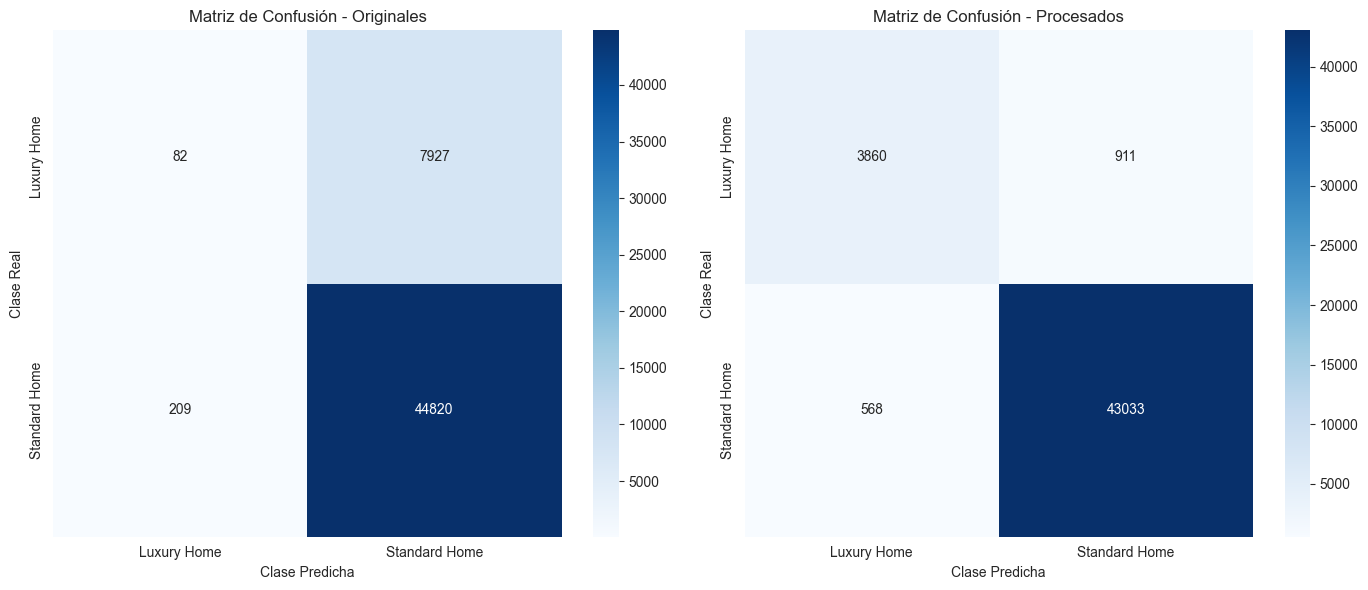

In [99]:
# Obtener etiquetas únicas de las clases en los datos originales y procesados
labels_orig = np.unique(np.concatenate((y_test_orig_class, y_pred_orig)))
labels_proc = np.unique(np.concatenate((y_test_proc_class, y_pred_proc)))

# Crear una figura con dos subgráficos en una fila
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión para datos originales
cm_orig = confusion_matrix(y_test_orig_class, y_pred_orig, labels=labels_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_orig, yticklabels=labels_orig, ax=axes[0])
axes[0].set_title('Matriz de Confusión - Originales')
axes[0].set_xlabel("Clase Predicha")
axes[0].set_ylabel("Clase Real")

# Matriz de confusión para datos procesados
cm_proc = confusion_matrix(y_test_proc_class, y_pred_proc, labels=labels_proc)
sns.heatmap(cm_proc, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_proc, yticklabels=labels_proc, ax=axes[1])
axes[1].set_title('Matriz de Confusión - Procesados')
axes[1].set_xlabel("Clase Predicha")
axes[1].set_ylabel("Clase Real")

# Ajustar diseño
plt.tight_layout()
plt.show()
